# Financial Econometrics I - Homework 2
#### **Authors:** Maxim Milde (`73267075`), Zahid Pashayev (`54520099`)
**Individual contributions**: Maxim Milde (construction of Problems 1-3), Zahid Pashayev (construction of Problems 4-6); cross-revision, refinement and elaboration by both students on all parts.

**AI tool usage**: Claude.ai was used for coding assistance (syntax - if not found in the seminars, debugging, R package usage) and as a discussion partner for improvement of concept understanding. All interpretation, reasoning, and written analysis is fully composed by the students.

**Data used**: 73267075

In [1]:
library(repr)
library(tseries)
library(forecast)
library(stats)
library(FinTS)
library(rugarch)
library(lmtest)

Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 

Loading required package: zoo


Attaching package: 'zoo'


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric



Attaching package: 'FinTS'


The following object is masked from 'package:forecast':

    Acf


Loading required package: parallel



In [3]:
seriesA <- read.csv("73267075/series_A.csv")
seriesB <- read.csv("73267075/series_B.csv")
seriesC <- read.csv("73267075/series_C.csv")

## Problem 1: Preliminary analysis

In [4]:
cat("Series A - Dimensions:", dim(seriesA), "\n"); head(seriesA)
cat("Series B - Dimensions:", dim(seriesB), "\n"); head(seriesB)
cat("Series C - Dimensions:", dim(seriesC), "\n"); head(seriesC)

Series A - Dimensions: 4000 3 


,t,ret,sigma2_true
,<int>,<dbl>,<dbl>
1,1,0.012729479,0.0001099423
2,2,-0.018529822,0.0001163126
3,3,0.007715439,0.0001683621
4,4,0.021651097,0.0001501986
5,5,-0.003913673,0.0001762050
6,6,-0.004157253,0.0001409973


Series B - Dimensions: 4000 3 


,t,ret,sigma2_true
,<int>,<dbl>,<dbl>
1,1,0.029356436,0.0003128726
2,2,0.016784537,0.0004485798
3,3,0.024271265,0.0003856098
4,4,-0.018726495,0.0004203585
5,5,-0.012681055,0.0004587874
6,6,-0.005705462,0.0003815353


Series C - Dimensions: 4000 3 


,t,ret,sigma2_true
,<int>,<dbl>,<dbl>
1,1,-0.0009315538,1e-04
2,2,0.0038711102,1e-04
3,3,0.0166130868,1e-04
4,4,0.0088461616,1e-04
5,5,0.0019757394,1e-04
6,6,-0.0134267758,1e-04


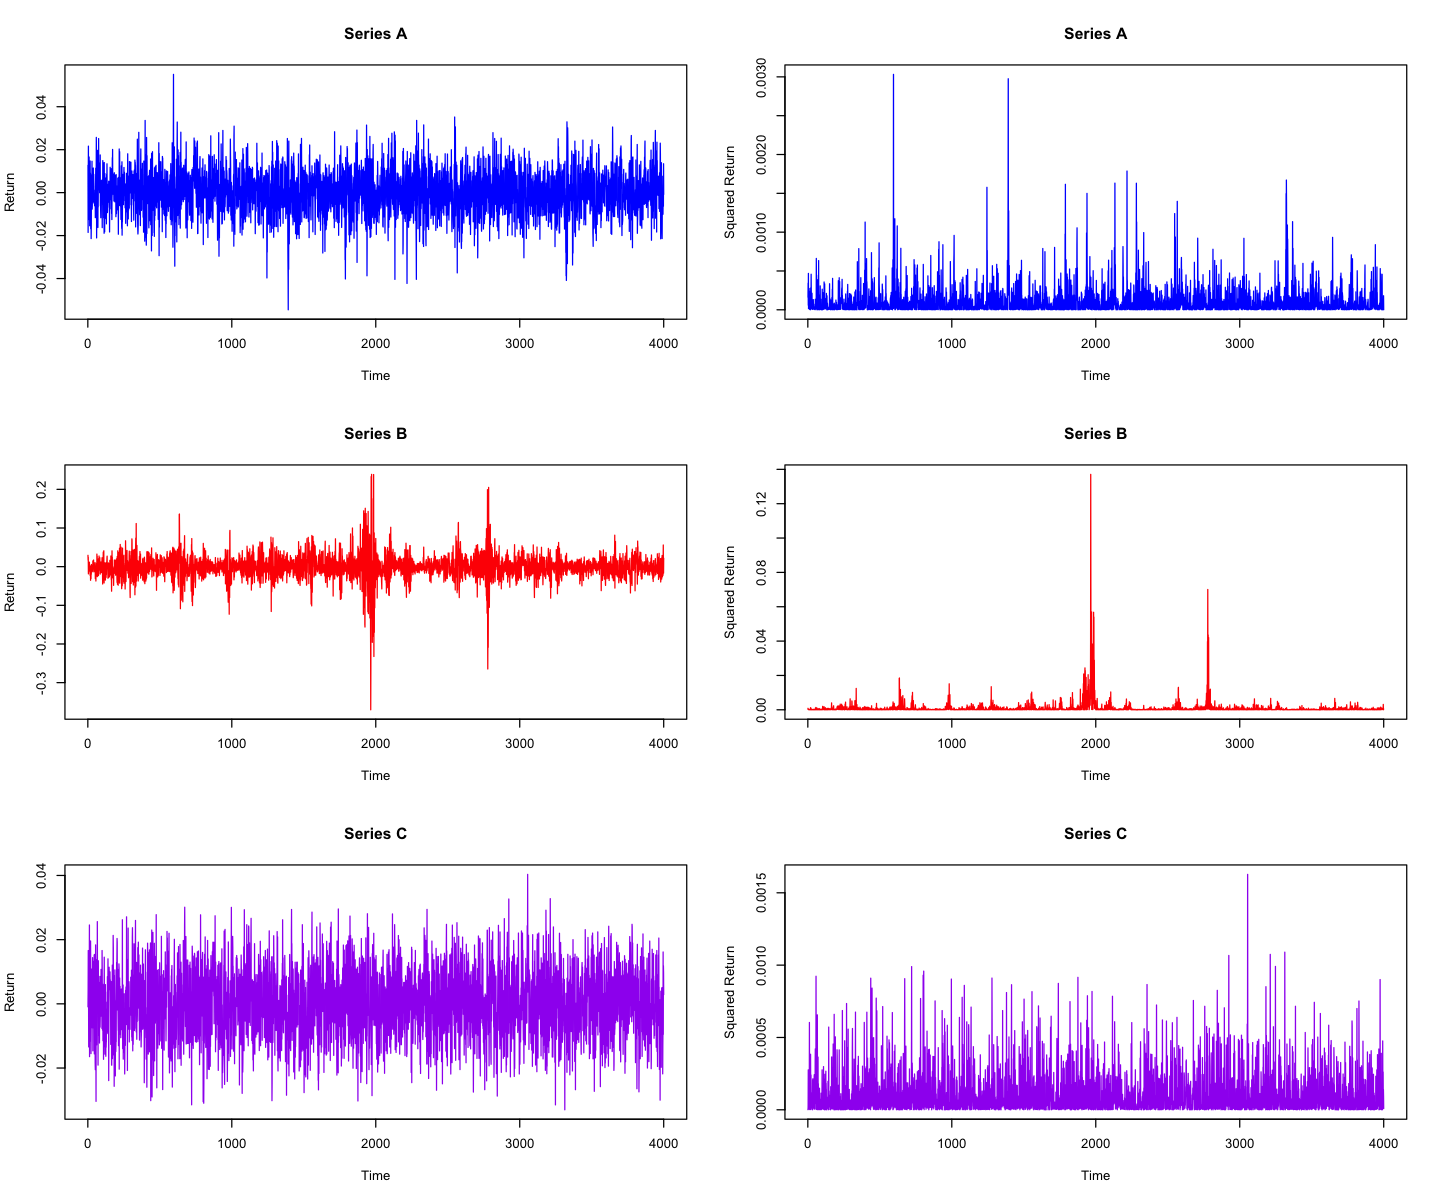

In [ ]:
options(repr.plot.height=10, repr.plot.width=12)
par(mfrow=c(3, 2))
ts.plot(seriesA$ret, col="blue", ylab="Return", main="Series A")
ts.plot(seriesA$ret^2, col="blue", ylab="Squared Return", main="Series A")

ts.plot(seriesB$ret, col="red", ylab="Return", main="Series B")
ts.plot(seriesB$ret^2, col="red", ylab="Squared Return", main="Series B")

ts.plot(seriesC$ret, col="purple", ylab="Return", main="Series C")
ts.plot(seriesC$ret^2, col="purple", ylab="Squared Return", main="Series C")

#note the difference in scale of the y-axis across series

From comparing both return series and return^2 series (proxy for volatility, since returns appear to have a mean close to 0), it appears that:
- **Series B**: while it exhibits the highest degree of volatility clustering (high alpha - reactiveness), it appears to be relatively short lived (the series mean-reverts quickly, moderate beta); strongest GARCH effects
- **Series A**: appears to be the series with moderate volatility clustering spread over the sample. Nevertheless the persistence of these clusters appear to last longer than Series B (higher beta).
- **Series C**: exhibits the lowest degree of GARCH dynamics - it has rather constant variance, with no sustained and obvious clustering.

**Initial hypothesis**: Series B exhibits the most persistent volatility clustering, Series A shows moderate persistence, and Series C appears closest to homoskedastic with no sustained clustering. To be confirmed from further analysis.

## Problem 2: Identification of the conditional mean

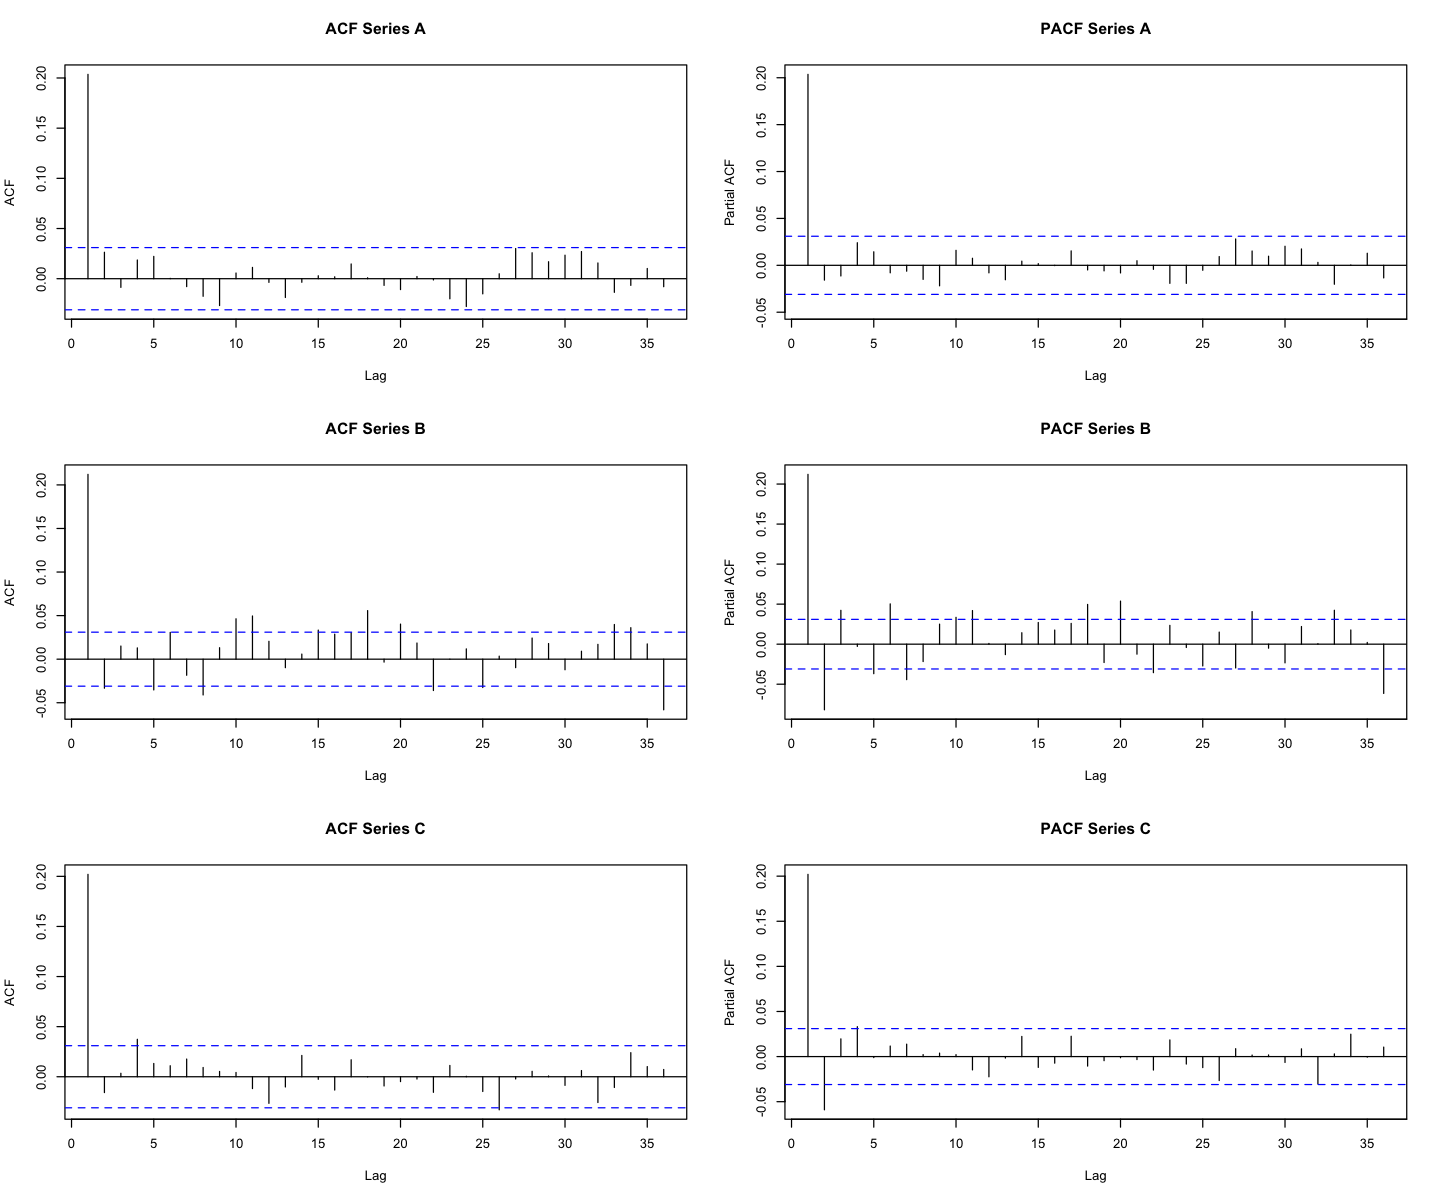

In [6]:
par(mfrow=c(3,2))
Acf(seriesA$ret, main="ACF Series A")
Pacf(seriesA$ret, main="PACF Series A")
Acf(seriesB$ret, main="ACF Series B")
Pacf(seriesB$ret, main="PACF Series B")
Acf(seriesC$ret, main="ACF Series C")
Pacf(seriesC$ret, main="PACF Series C")

Potential ARMA specifications based on ACF/PACF:

**Series A**: ARMA(0,1), ARMA(0,0), ARMA(1,1) (unlikely)
- The ACF cuts off after the first lag, every other is whithin confidence bands - this suggests MA(1). The $\theta$ coefficient being very small could justify the sharp cutoff in PACF. It could also simply be white noise (ARMA(0,0)), since all but 1 lags are within conficence bands.

**Series B**: ARMA(7,2), ARMA(3,1), ARMA(3,2) 
- It becomes very hard to judge the process, as the significance of lag autocorrelations persist at high lags and no clear cutoff pattern
- High order ARMA is likely overfitting from GARCH contamination

**Series C**: ARMA(2,1), ARMA(4,0), ARMA(0,4)
- Lags 1 and 4 are significant in ACF, suggesting MA up to order 4, however 1st lag in ACF and 2nd in PACF seem the most significant
- Lags 1, 2, 4 are significant in PACF, suggesting AR of order up to 4
---

### Model fitting
#### Series A

Series: seriesA$ret 
ARIMA(0,0,1) with non-zero mean 

Coefficients:
         ma1   mean
      0.1999  2e-04
s.e.  0.0150  2e-04

sigma^2 = 0.0001019:  log likelihood = 12707.3
AIC=-25408.61   AICc=-25408.6   BIC=-25389.72

Training set error measures:
                        ME       RMSE         MAE      MPE     MAPE      MASE
Training set -2.603314e-07 0.01009445 0.007882723 1355.575 1465.362 0.7847918
                    ACF1
Training set 0.006410327


	Box-Ljung test

data:  a_arma01$residuals
X-squared = 6.0273, df = 4, p-value = 0.1971



	Box-Ljung test

data:  a_arma01$residuals
X-squared = 8.1659, df = 8, p-value = 0.4174



	Box-Ljung test

data:  a_arma01$residuals
X-squared = 11.665, df = 12, p-value = 0.473


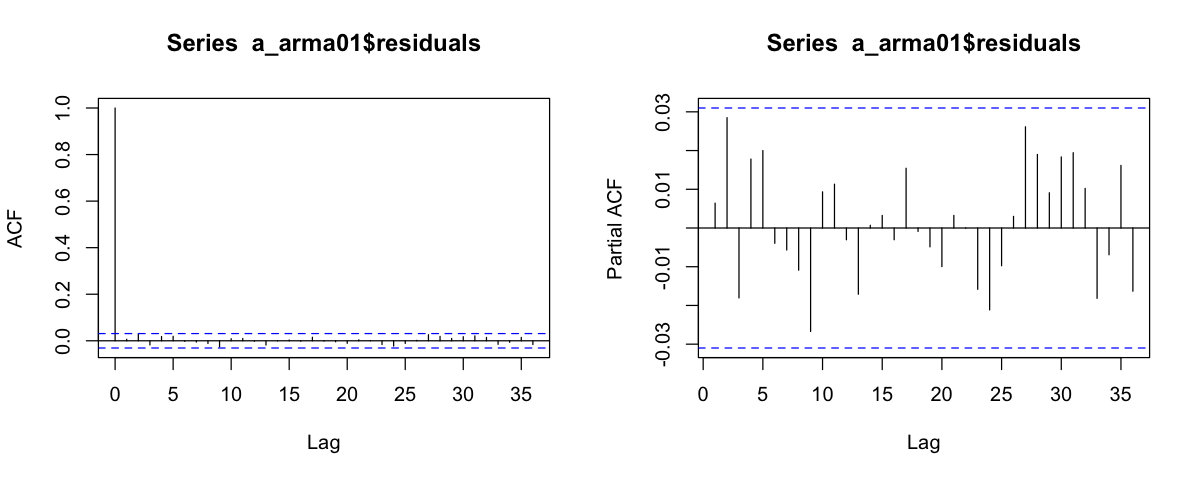

In [7]:
a_arma01 <- Arima(seriesA$ret, order=c(0,0,1))
summary(a_arma01)

options(repr.plot.height=4, repr.plot.width=10)
par(mfrow=c(1,2))
acf(a_arma01$residuals)
pacf(a_arma01$residuals)

Box.test(a_arma01$residuals, type="Ljung-Box", lag=4)
Box.test(a_arma01$residuals, type="Ljung-Box", lag=8)
Box.test(a_arma01$residuals, type="Ljung-Box", lag=12)

We fail to reject the null of joint insignificance of residual autocorrelation.

Series: seriesA$ret 
ARIMA(0,0,0) with non-zero mean 

Coefficients:
       mean
      2e-04
s.e.  2e-04

sigma^2 = 0.0001063:  log likelihood = 12623.99
AIC=-25243.98   AICc=-25243.97   BIC=-25231.39

Training set error measures:
                       ME       RMSE         MAE       MPE     MAPE     MASE
Training set 8.682665e-16 0.01030696 0.007992027 -42.08775 247.7776 0.795674
                  ACF1
Training set 0.2036069


	Box-Ljung test

data:  a_arma00$residuals
X-squared = 170.41, df = 4, p-value < 2.2e-16



	Box-Ljung test

data:  a_arma00$residuals
X-squared = 173.87, df = 8, p-value < 2.2e-16



	Box-Ljung test

data:  a_arma00$residuals
X-squared = 177.42, df = 12, p-value < 2.2e-16


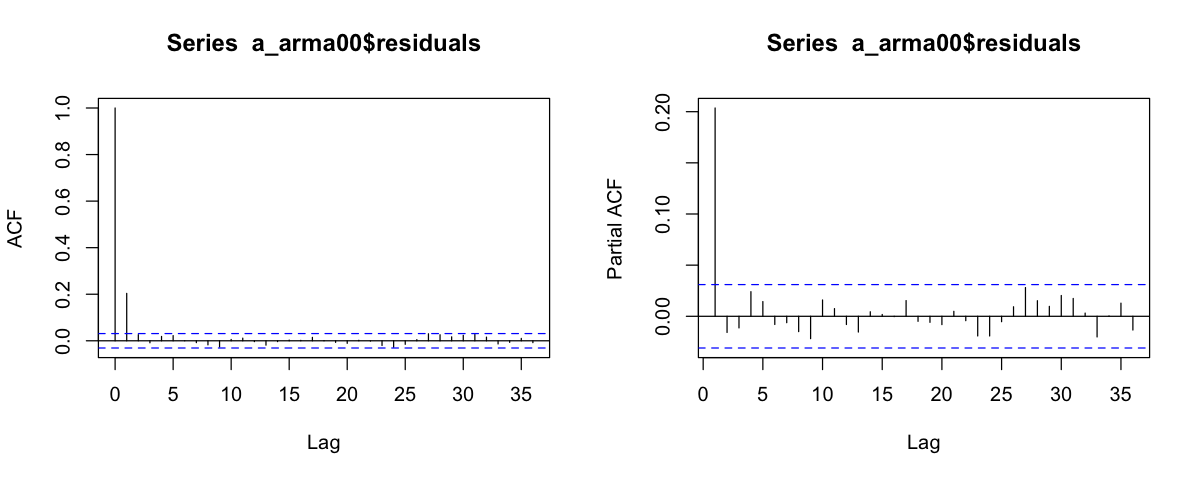

In [8]:
a_arma00 <- Arima(seriesA$ret, order=c(0,0,0))
summary(a_arma00)

par(mfrow=c(1,2))
acf(a_arma00$residuals)
pacf(a_arma00$residuals)

Box.test(a_arma00$residuals, type="Ljung-Box", lag=4)
Box.test(a_arma00$residuals, type="Ljung-Box", lag=8)
Box.test(a_arma00$residuals, type="Ljung-Box", lag=12)

From the ACF and the formal test, we observe that ARMA(0,0) does not eliminate residual autocorrelation - the null of joint insignificance is rejected for all lags tested. There must be an exploitable mean structure.

Series: seriesA$ret 
ARIMA(1,0,1) with non-zero mean 

Coefficients:
         ar1     ma1   mean
      0.1381  0.0684  2e-04
s.e.  0.0713  0.0716  2e-04

sigma^2 = 0.0001019:  log likelihood = 12709.13
AIC=-25410.25   AICc=-25410.24   BIC=-25385.08

Training set error measures:
                       ME       RMSE         MAE      MPE     MAPE      MASE
Training set 1.343319e-07 0.01008985 0.007880469 1538.757 1654.216 0.7845675
                   ACF1
Training set 9.9461e-05


	Box-Ljung test

data:  a_arma11$residuals
X-squared = 2.3767, df = 4, p-value = 0.6668



	Box-Ljung test

data:  a_arma11$residuals
X-squared = 4.5962, df = 8, p-value = 0.7997



	Box-Ljung test

data:  a_arma11$residuals
X-squared = 8.2631, df = 12, p-value = 0.7642


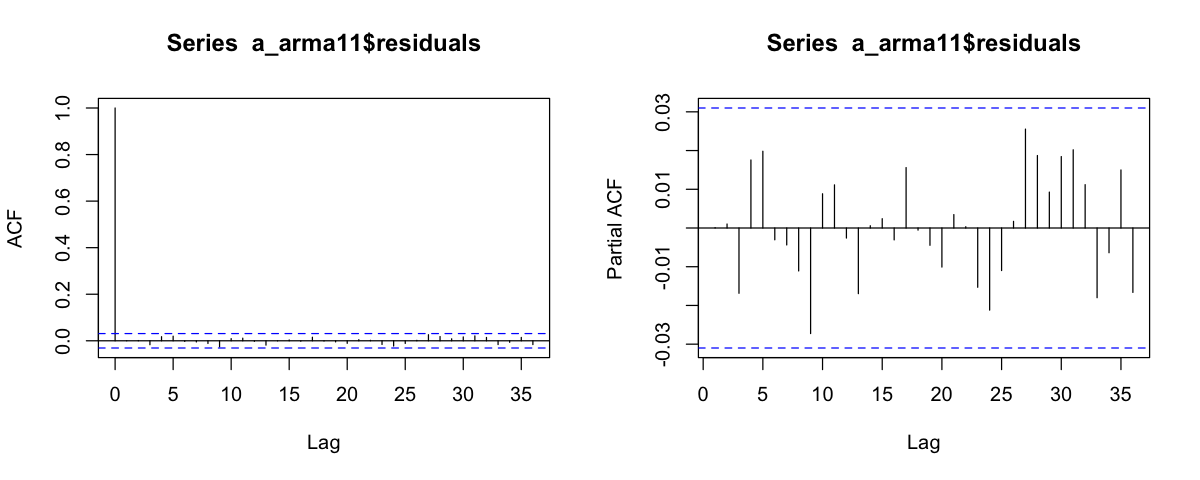

In [9]:
a_arma11 <- Arima(seriesA$ret, order=c(1,0,1))
summary(a_arma11)

par(mfrow=c(1,2))
acf(a_arma11$residuals)
pacf(a_arma11$residuals)

Box.test(a_arma11$residuals, type="Ljung-Box", lag=4)
Box.test(a_arma11$residuals, type="Ljung-Box", lag=8)
Box.test(a_arma11$residuals, type="Ljung-Box", lag=12)

In contrast, ARMA(1,1) is appropriate as indicated by both the inability to reject of the null of joint residual autocorrelation and the ACF - we do not observe residual autocorrelation after fitting this model.

Series: seriesA$ret 
ARIMA(1,0,0) with non-zero mean 

Coefficients:
         ar1   mean
      0.2036  2e-04
s.e.  0.0155  2e-04

sigma^2 = 0.0001019:  log likelihood = 12708.68
AIC=-25411.36   AICc=-25411.35   BIC=-25392.47

Training set error measures:
                        ME       RMSE         MAE      MPE     MAPE      MASE
Training set -7.247933e-09 0.01009098 0.007879242 1587.931 1701.394 0.7844453
                    ACF1
Training set 0.003204518


	Box-Ljung test

data:  a_arma10$residuals
X-squared = 3.34, df = 4, p-value = 0.5026



	Box-Ljung test

data:  a_arma10$residuals
X-squared = 5.6332, df = 8, p-value = 0.6882



	Box-Ljung test

data:  a_arma10$residuals
X-squared = 9.3926, df = 12, p-value = 0.6691


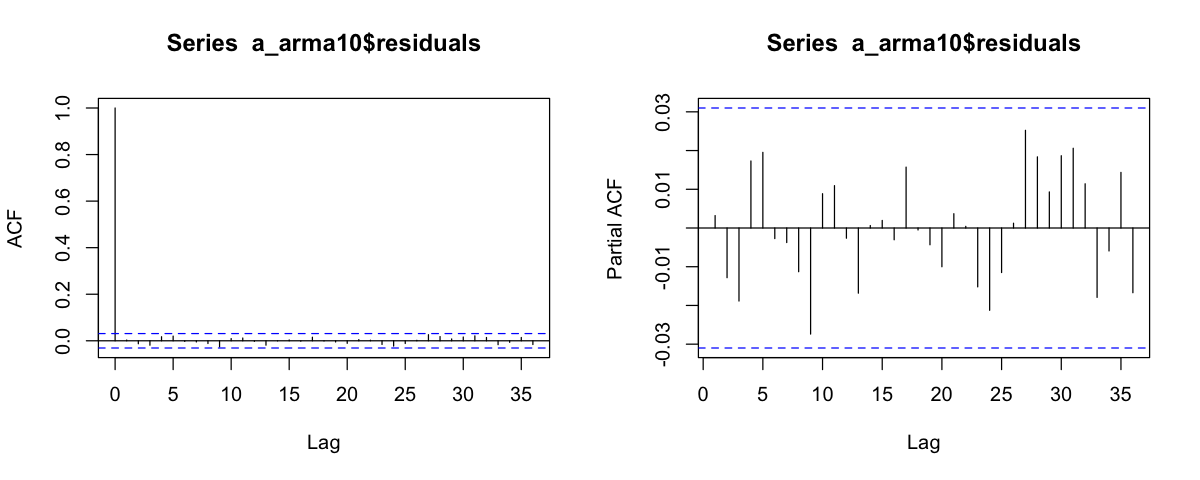

In [10]:
a_arma10 <- Arima(seriesA$ret, order=c(1,0,0))
summary(a_arma10)

par(mfrow=c(1,2))
acf(a_arma10$residuals)
pacf(a_arma10$residuals)

Box.test(a_arma10$residuals, type="Ljung-Box", lag=4)
Box.test(a_arma10$residuals, type="Ljung-Box", lag=8)
Box.test(a_arma10$residuals, type="Ljung-Box", lag=12)

Upon further inspection, it appears that ARMA(1,0) is more appropriate candidate than some of the hypothesized ones above. We cannot reject the null and the ACF and PACF show no residual autocorrelation.

**Top candidates for series A**:
- ARMA(0,1)
- ARMA(1,0)
- ARMA(1,1)
---

#### Series B

Series: seriesB$ret 
ARIMA(7,0,2) with non-zero mean 

Coefficients:
         ar1      ar2     ar3      ar4      ar5     ar6      ar7      ma1
      0.6878  -0.7747  0.2135  -0.0579  -0.0321  0.0764  -0.0824  -0.4536
s.e.  0.1402   0.1343  0.0404   0.0268   0.0236  0.0195   0.0169   0.1404
         ma2    mean
      0.5801  -8e-04
s.e.  0.1253   6e-04

sigma^2 = 0.000928:  log likelihood = 8294.14
AIC=-16566.29   AICc=-16566.22   BIC=-16497.05

Training set error measures:
                       ME       RMSE        MAE      MPE     MAPE      MASE
Training set 3.231685e-05 0.03042503 0.02007446 132.6448 213.5471 0.7821786
                    ACF1
Training set 0.001331049


	Box-Ljung test

data:  b_arma72$residuals
X-squared = 0.046735, df = 4, p-value = 0.9997



	Box-Ljung test

data:  b_arma72$residuals
X-squared = 1.3152, df = 8, p-value = 0.9954



	Box-Ljung test

data:  b_arma72$residuals
X-squared = 9.4281, df = 12, p-value = 0.666



	Box-Ljung test

data:  b_arma72$residuals
X-squared = 76.153, df = 35, p-value = 7.003e-05


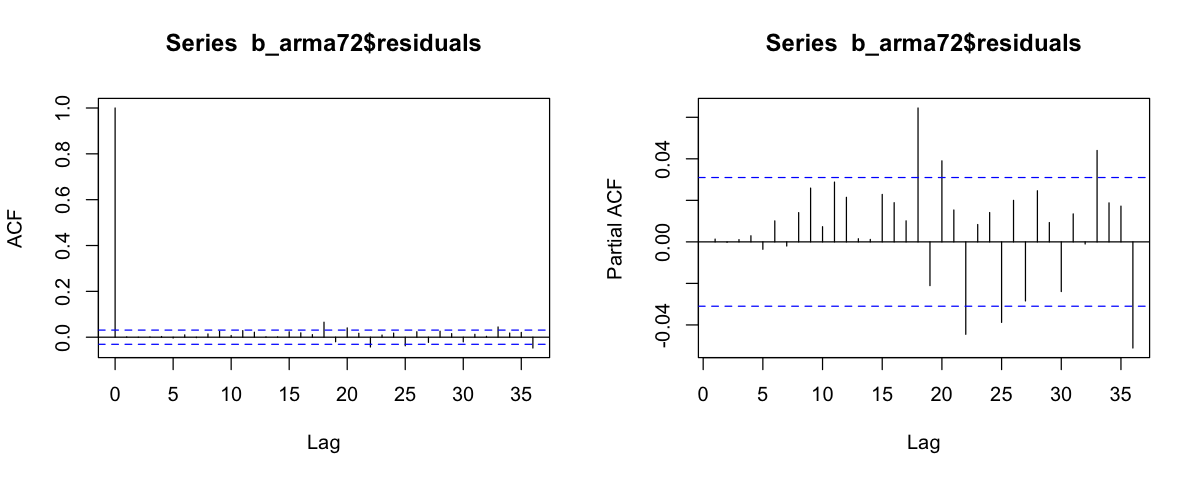

In [11]:
b_arma72 <- Arima(seriesB$ret, order=c(7,0,2))
summary(b_arma72)

par(mfrow=c(1,2))
acf(b_arma72$residuals)
pacf(b_arma72$residuals)

Box.test(b_arma72$residuals, type="Ljung-Box", lag=4)
Box.test(b_arma72$residuals, type="Ljung-Box", lag=8)
Box.test(b_arma72$residuals, type="Ljung-Box", lag=12)
Box.test(b_arma72$residuals, type="Ljung-Box", lag=35)

While all coefficients appear to be significant, the Ljung-Box null cannot be rejected (for lower lags), we observe high autocorrelation at higher lags (PACF), which is also strongly supported by the formal test.
These results strongly suggest GARCH contamination and that any order ARMA we attempt to fit, will either be innapropriate, or overfit the data.
Given that residual autocorrelation persists at high lags even under ARMA(7,2), the initially hypothesised lower-order specifications ARMA(3,1) and ARMA(3,2) would perform no better. We therefore depart from those candidates and instead explore higher-order alternatives — ARMA(15,1) and ARMA(6,6) — to test the limits of pure ARMA modeling for this series and further demonstrate the likely presence of GARCH contamination.

Series: seriesB$ret 
ARIMA(15,0,1) with non-zero mean 

Coefficients:
         ar1      ar2     ar3      ar4      ar5     ar6      ar7     ar8
      0.9843  -0.2653  0.1046  -0.0162  -0.0641  0.0986  -0.0806  0.0014
s.e.  0.1112   0.0341  0.0247   0.0230   0.0227  0.0234   0.0237  0.0231
         ar9    ar10    ar11    ar12     ar13    ar14    ar15      ma1    mean
      0.0405  0.0094  0.0216  -0.026  -0.0175  0.0189  0.0221  -0.7521  -7e-04
s.e.  0.0229  0.0228  0.0228   0.023   0.0226  0.0224  0.0175   0.1104   7e-04

sigma^2 = 0.0009252:  log likelihood = 8303.6
AIC=-16571.2   AICc=-16571.03   BIC=-16457.91

Training set error measures:
                       ME       RMSE        MAE      MPE     MAPE      MASE
Training set 6.463701e-06 0.03035293 0.02005657 129.5991 222.9638 0.7814816
                      ACF1
Training set -7.623954e-05


	Box-Ljung test

data:  b_arma_bigAR$residuals
X-squared = 0.0058571, df = 4, p-value = 1



	Box-Ljung test

data:  b_arma_bigAR$residuals
X-squared = 0.012233, df = 8, p-value = 1



	Box-Ljung test

data:  b_arma_bigAR$residuals
X-squared = 0.058958, df = 12, p-value = 1



	Box-Ljung test

data:  b_arma_bigAR$residuals
X-squared = 101.02, df = 40, p-value = 3.467e-07


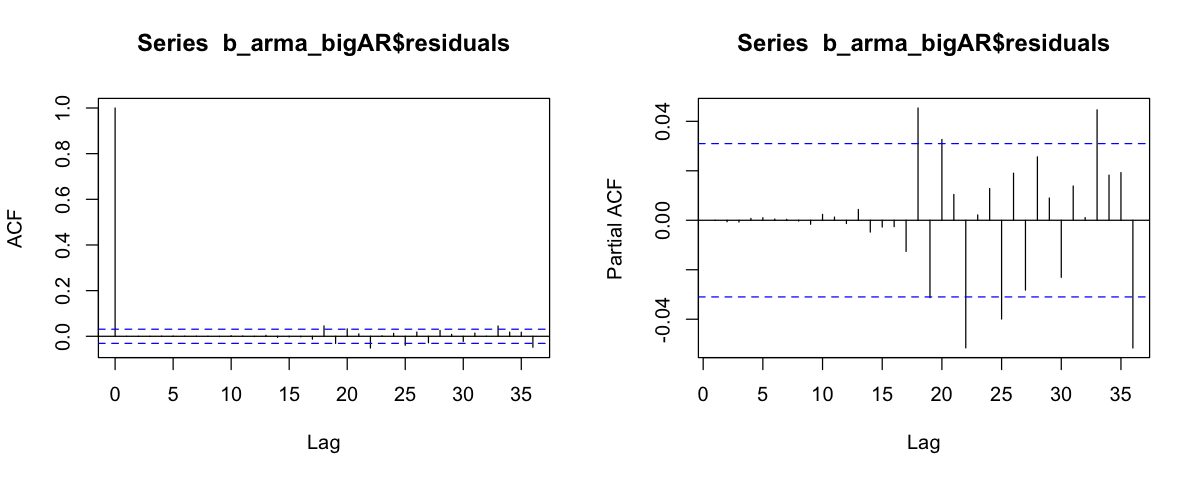

In [12]:
b_arma_bigAR <- Arima(seriesB$ret, order=c(15,0,1))
summary(b_arma_bigAR)

par(mfrow=c(1,2))
acf(b_arma_bigAR$residuals)
pacf(b_arma_bigAR$residuals)

Box.test(b_arma_bigAR$residuals, type="Ljung-Box", lag=4)
Box.test(b_arma_bigAR$residuals, type="Ljung-Box", lag=8)
Box.test(b_arma_bigAR$residuals, type="Ljung-Box", lag=12)
Box.test(b_arma_bigAR$residuals, type="Ljung-Box", lag=40)

It is evident that in order to eliminate the residual autocorrelation in PACF by fitting only an ARMA model, it would necessitate very high order AR terms. The MA part appears to be around 1. Attempting to fit more ARMA models to this series is of no use, as we will likely be overfitting the model instead. Nevertheless, we continue as per assignment.

Series: seriesB$ret 
ARIMA(6,0,6) with non-zero mean 

Coefficients:
         ar1      ar2     ar3      ar4     ar5      ar6      ma1     ma2
      0.8029  -1.2268  0.3177  -0.5684  0.0767  -0.3543  -0.5696  1.0055
s.e.  0.2682   0.2106  0.3901   0.2475  0.2055   0.0983   0.2707  0.1645
         ma3     ma4     ma5     ma6    mean
      0.0085  0.4695  0.0141  0.4086  -7e-04
s.e.  0.3445  0.1693  0.1614  0.0728   6e-04

sigma^2 = 0.0009263:  log likelihood = 8299.2
AIC=-16570.41   AICc=-16570.3   BIC=-16482.29

Training set error measures:
                        ME       RMSE       MAE      MPE     MAPE      MASE
Training set -4.174933e-05 0.03038641 0.0200811 131.4886 214.8241 0.7824373
                   ACF1
Training set 0.00105286


	Box-Ljung test

data:  b_arma66$residuals
X-squared = 0.034429, df = 4, p-value = 0.9999



	Box-Ljung test

data:  b_arma66$residuals
X-squared = 0.6516, df = 8, p-value = 0.9996



	Box-Ljung test

data:  b_arma66$residuals
X-squared = 2.2345, df = 12, p-value = 0.999



	Box-Ljung test

data:  b_arma66$residuals
X-squared = 65.635, df = 35, p-value = 0.001295


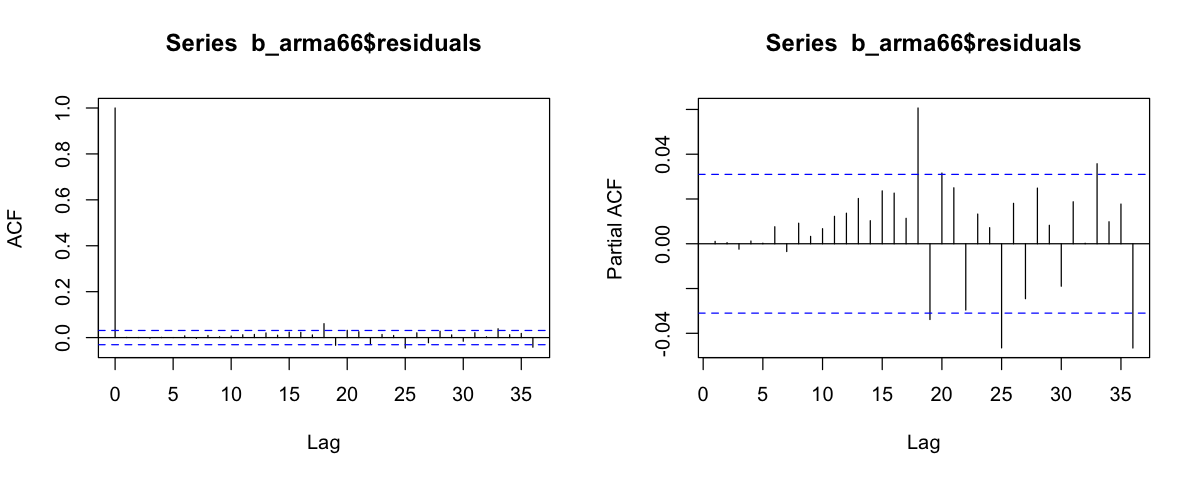

In [13]:
b_arma66 <- Arima(seriesB$ret, order=c(6,0,6))
summary(b_arma66)

par(mfrow=c(1,2))
acf(b_arma66$residuals)
pacf(b_arma66$residuals)

Box.test(b_arma66$residuals, type="Ljung-Box", lag=4)
Box.test(b_arma66$residuals, type="Ljung-Box", lag=8)
Box.test(b_arma66$residuals, type="Ljung-Box", lag=12)
Box.test(b_arma66$residuals, type="Ljung-Box", lag=35)

This model performs similarly to ARMA(15,1). 

**Best candidate**:
- ARMA(15,1)
- ARMA(6,6)

However, we know that these are not appropriate.

#### Series C

Series: seriesC$ret 
ARIMA(2,0,1) with non-zero mean 

Coefficients:
         ar1      ar2     ma1   mean
      0.1046  -0.0379  0.1101  2e-04
s.e.  0.1768   0.0391  0.1767  2e-04

sigma^2 = 0.0001025:  log likelihood = 12698.35
AIC=-25386.7   AICc=-25386.68   BIC=-25355.23

Training set error measures:
                       ME       RMSE         MAE      MPE     MAPE      MASE
Training set 1.985483e-08 0.01011707 0.008070224 73.77629 180.9371 0.7784902
                     ACF1
Training set 0.0002081961


	Box-Ljung test

data:  c_arma21$residuals
X-squared = 5.3002, df = 4, p-value = 0.2579



	Box-Ljung test

data:  c_arma21$residuals
X-squared = 6.7053, df = 8, p-value = 0.5687



	Box-Ljung test

data:  c_arma21$residuals
X-squared = 9.0996, df = 12, p-value = 0.6944


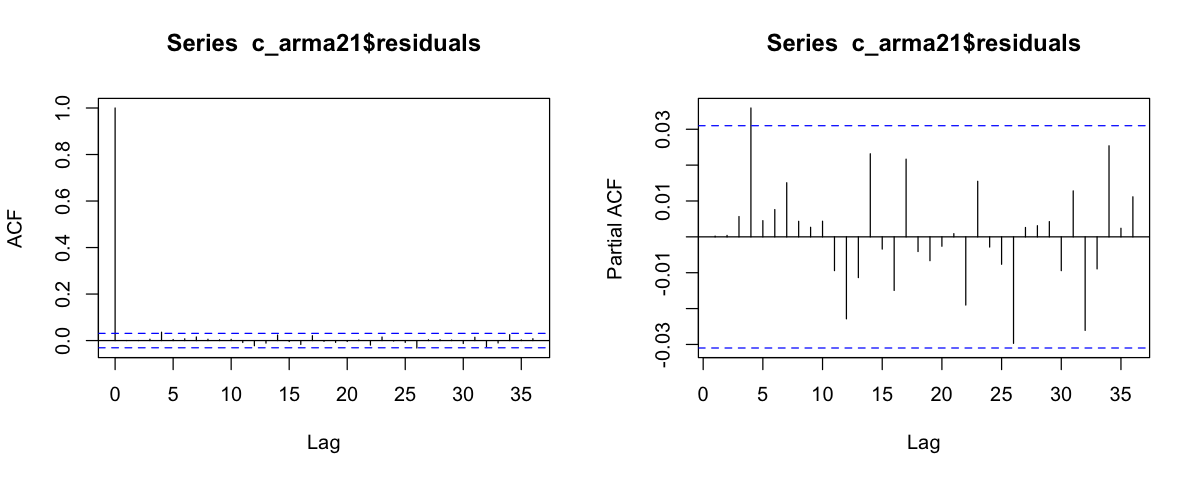

In [14]:
c_arma21 <- Arima(seriesC$ret, order=c(2,0,1))
summary(c_arma21)

par(mfrow=c(1,2))
acf(c_arma21$residuals)
pacf(c_arma21$residuals)

Box.test(c_arma21$residuals, type="Ljung-Box", lag=4)
Box.test(c_arma21$residuals, type="Ljung-Box", lag=8)
Box.test(c_arma21$residuals, type="Ljung-Box", lag=12)

None of the coefficients show to be significant (coeff/s.e.).
Nevertheless, we cannot reject the null of insignificant residual autocorrelation at any of the examined lags. However, we still see one lag (4) in the PACF to be outside of the confidence bounds. We will therefore test ARMA(4,0)

Series: seriesC$ret 
ARIMA(4,0,0) with non-zero mean 

Coefficients:
         ar1      ar2     ar3     ar4   mean
      0.2144  -0.0611  0.0125  0.0332  2e-04
s.e.  0.0158   0.0162  0.0162  0.0158  2e-04

sigma^2 = 0.0001023:  log likelihood = 12700.98
AIC=-25389.97   AICc=-25389.95   BIC=-25352.2

Training set error measures:
                       ME      RMSE         MAE      MPE     MAPE      MASE
Training set 6.776323e-07 0.0101104 0.008064675 71.72275 189.3922 0.7779549
                    ACF1
Training set 6.30207e-05


	Box-Ljung test

data:  c_arma40$residuals
X-squared = 0.0040583, df = 4, p-value = 1



	Box-Ljung test

data:  c_arma40$residuals
X-squared = 1.4177, df = 8, p-value = 0.994



	Box-Ljung test

data:  c_arma40$residuals
X-squared = 3.7955, df = 12, p-value = 0.9869


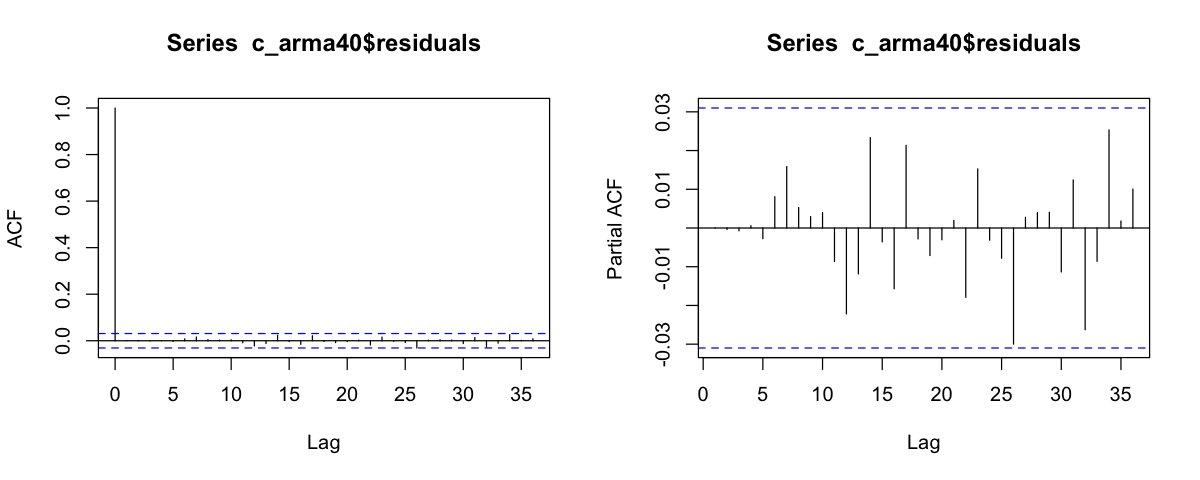

In [15]:
c_arma40 <- Arima(seriesC$ret, order=c(4,0,0))
summary(c_arma40)

par(mfrow=c(1,2))
acf(c_arma40$residuals)
pacf(c_arma40$residuals)

Box.test(c_arma40$residuals, type="Ljung-Box", lag=4)
Box.test(c_arma40$residuals, type="Ljung-Box", lag=8)
Box.test(c_arma40$residuals, type="Ljung-Box", lag=12)

Hereby, all residual autocorrelations disappear. We cannot reject the null and the ACF and PACF do not exhibit peculiar behaviour. We are inclined to believe this could be close to the data generating model.

Series: seriesC$ret 
ARIMA(0,0,4) with non-zero mean 

Coefficients:
         ma1      ma2      ma3     ma4   mean
      0.2141  -0.0153  -0.0049  0.0338  2e-04
s.e.  0.0158   0.0161   0.0160  0.0156  2e-04

sigma^2 = 0.0001024:  log likelihood = 12700.74
AIC=-25389.48   AICc=-25389.46   BIC=-25351.71

Training set error measures:
                       ME       RMSE         MAE      MPE     MAPE      MASE
Training set 5.143586e-08 0.01011101 0.008067254 73.66759 186.5105 0.7782037
                     ACF1
Training set 0.0004494463


	Box-Ljung test

data:  c_arma04$residuals
X-squared = 0.027263, df = 4, p-value = 0.9999



	Box-Ljung test

data:  c_arma04$residuals
X-squared = 1.8539, df = 8, p-value = 0.9852



	Box-Ljung test

data:  c_arma04$residuals
X-squared = 4.1734, df = 12, p-value = 0.9801


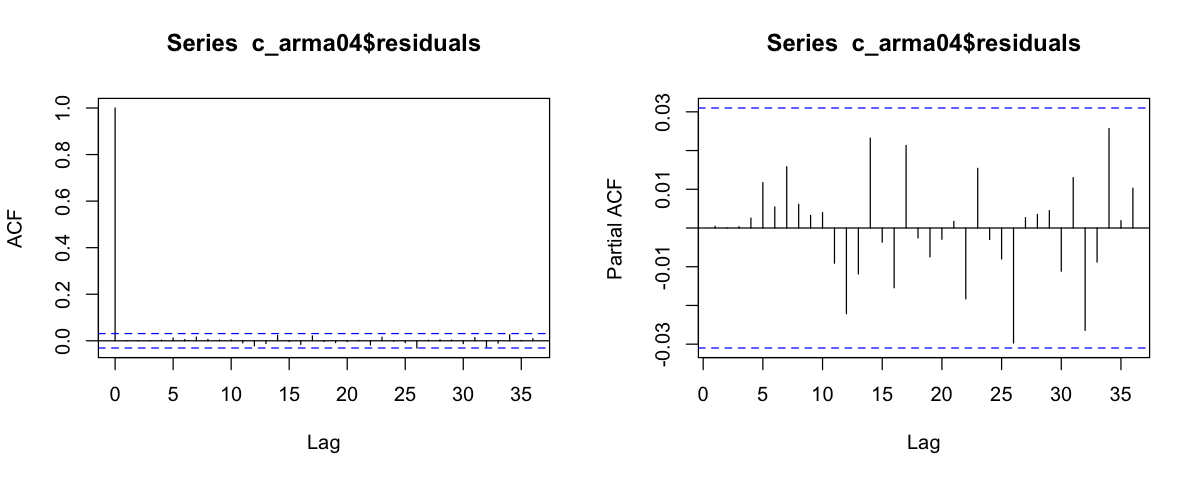

In [16]:
c_arma04 <- Arima(seriesC$ret, order=c(0,0,4))
summary(c_arma04)

par(mfrow=c(1,2))
acf(c_arma04$residuals)
pacf(c_arma04$residuals)

Box.test(c_arma04$residuals, type="Ljung-Box", lag=4)
Box.test(c_arma04$residuals, type="Ljung-Box", lag=8)
Box.test(c_arma04$residuals, type="Ljung-Box", lag=12)

Upon further inspection, ARMA(0,4) also provides a good fit, similar to ARMA(4,0). The behaviour is similar if we even attempt ARMA(4,4) as it can be seen below.

Warning message in sqrt(diag(x$var.coef)):
"NaNs produced"


Series: seriesC$ret 
ARIMA(4,0,4) with non-zero mean 

Coefficients:
         ar1     ar2     ar3     ar4     ma1      ma2      ma3      ma4   mean
      0.1366  0.1202  0.1856  0.0475  0.0776  -0.1646  -0.2132  -0.0471  2e-04
s.e.     NaN     NaN  0.4394     NaN     NaN   0.2798   0.2400      NaN  2e-04

sigma^2 = 0.0001024:  log likelihood = 12701.43
AIC=-25382.85   AICc=-25382.8   BIC=-25319.91

Training set error measures:
                        ME       RMSE         MAE      MPE     MAPE      MASE
Training set -2.108073e-06 0.01010927 0.008065659 69.93039 188.3426 0.7780498
                     ACF1
Training set 0.0001389742


	Box-Ljung test

data:  c_arma44$residuals
X-squared = 0.0083559, df = 4, p-value = 1



	Box-Ljung test

data:  c_arma44$residuals
X-squared = 0.29443, df = 8, p-value = 1



	Box-Ljung test

data:  c_arma44$residuals
X-squared = 2.8545, df = 12, p-value = 0.9965


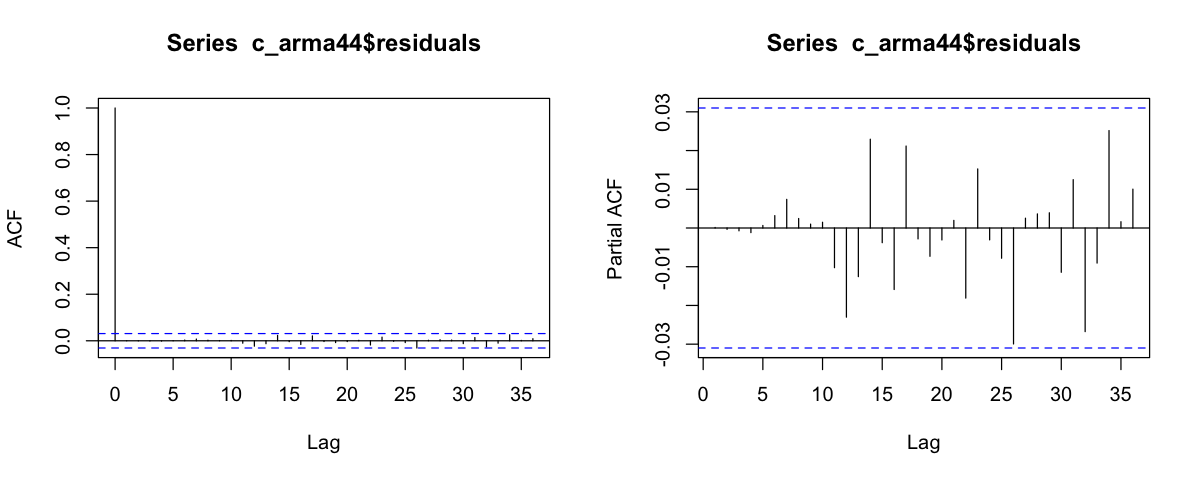

In [17]:
c_arma44 <- Arima(seriesC$ret, order=c(4,0,4))
summary(c_arma44)

par(mfrow=c(1,2))
acf(c_arma44$residuals)
pacf(c_arma44$residuals)

Box.test(c_arma44$residuals, type="Ljung-Box", lag=4)
Box.test(c_arma44$residuals, type="Ljung-Box", lag=8)
Box.test(c_arma44$residuals, type="Ljung-Box", lag=12)

However, this is not the most parsimonuous model and we are likely overfitting at this stage.

**Best candidate models**:
- ARMA(4,0)
- ARMA(0,4)

`Side note`: splitting the model into sub-periods and considering different models for separate periods has not been considered, as we believe the assignment does not ask for that.

---

### Information Criteria comparison

In [18]:
#Put all ICs into a dataframe to present collectively
ic_A <- data.frame(
    Model = c("ARMA(0,1)", "ARMA(1,0)", "ARMA(1,1)"),
    AIC = c(a_arma01$aic, a_arma10$aic, a_arma11$aic),
    AICc = c(a_arma01$aicc, a_arma10$aicc, a_arma11$aicc),
    BIC = c(a_arma01$bic, a_arma10$bic, a_arma11$bic)
)

ic_B <- data.frame(
    Model = c("ARMA(7,2)", "ARMA(15,1)", "ARMA(6,6)"),
    AIC = c(b_arma72$aic, b_arma_bigAR$aic, b_arma66$aic),
    AICc = c(b_arma72$aicc, b_arma_bigAR$aicc, b_arma66$aicc),
    BIC = c(b_arma72$bic, b_arma_bigAR$bic, b_arma66$bic)
)

ic_C <- data.frame(
    Model = c("ARMA(4,0)", "ARMA(0,4)", "ARMA(4,4)"),
    AIC = c(c_arma40$aic, c_arma04$aic, c_arma44$aic),
    AICc = c(c_arma40$aicc, c_arma04$aicc, c_arma44$aicc),
    BIC = c(c_arma40$bic, c_arma04$bic, c_arma44$bic)
)

ic_all <- rbind(
    cbind(Series="A", ic_A),
    cbind(Series="B", ic_B),
    cbind(Series="C", ic_C)
)
ic_all

Series,Model,AIC,AICc,BIC
<chr>,<chr>,<dbl>,<dbl>,<dbl>
A,"ARMA(0,1)",-25408.61,-25408.60,-25389.72
A,"ARMA(1,0)",-25411.36,-25411.35,-25392.47
A,"ARMA(1,1)",-25410.25,-25410.24,-25385.08
B,"ARMA(7,2)",-16566.29,-16566.22,-16497.05
B,"ARMA(15,1)",-16571.20,-16571.03,-16457.91
B,"ARMA(6,6)",-16570.41,-16570.30,-16482.29
C,"ARMA(4,0)",-25389.97,-25389.95,-25352.20
C,"ARMA(0,4)",-25389.48,-25389.46,-25351.71
C,"ARMA(4,4)",-25382.85,-25382.80,-25319.91


The three examined criteria are defined as follows:

$$AIC = -2\ell(\hat{\theta}) + 2k$$

$$AICc = AIC + \frac{2k(k+1)}{n-k-1}$$

$$BIC = -2\ell(\hat{\theta}) + k\ln(n)$$

where $\ell(\hat{\theta})$ is the log-likelihood evaluated at the estimated parameters,
$k$ is the number of estimated parameters, and $n$ is the sample size.

The AIC and AICc differ with respect to penalization - AIC and AICc both reward fit and penalise complexity. AICc, however, introduces an additional correction term which penalises small sample sizes. Since our series samples are large, AIC and AICc are almost identical.

BIC: The penalty term $k\ln(n)$ grows with both the number of parameters $k$ and 
sample size $n$. For $n > e^2 \approx 7.4$, $\ln(n) > 2$. This means BIC always 
penalises complexity more heavily than AIC. With $n=4000$, $\ln(n) \approx 8.3$, 
around 4x the AIC penalty per parameter.


**Series A**:
Both ARMA(0,1) and ARMA(1, 0) perform similarly across all criteria, with ARMA(1,0) being negligably preferred across criteria. This suggests that both specifications model the mean equally well.

**Series B**:
AIC/AICc slightly prefer ARMA(15,1). BIC in turn prefers ARMA(6,6) as it finds it to be the more parsimonious specification. Since we suspected Series B to have the highest magnitude of GARCH effects, both specifications examined likely represent overfitting risk.

**Series C**: 
All three candidates perform similarly. AIC prefer ARMA(4,0) slightly (the difference is negligible), similar to BIC (which penalises the more complex ARMA(4,4))

---
Based on the information criteria and ACF/PACF graphs (for the examined specifications), we find the most appropriate ones to be:

**Series A**: ARMA(1,0)
- Unanimously selected by the information criteria by a small amount. Nevertheless, if it were truly an AR(1) process,while we would expect to have 1 significant lag at the PACF, we would also expect to see a slowly decaying ACF (it could be that the memory of this process is very short)

**Series B**: ARMA(6,6)
- The BIC finds the order 6,6 to be less complex, while the AIC(c) does not differentiate substantially between the two models. Neither model manages to eliminate completely the residual autocorrelation - remaining dynamics likely GARCH. This selection is provisional — if the residual autocorrelation is confirmed to stem from GARCH contamination rather than true mean dynamics in Problem 3, a more parsimonious mean specification may be adopted at the GARCH estimation stage.

**Series C**: ARMA(4,0)
- (4,4) is penalised for complexity, while (4,0) and (0,4) differ minimally based on the criteria. (4,0) has slightly more negative criteria. Such a finding is rather consistent with the PACF, as we see a cutoff around lag 4, while the ACF appears to be decaying in some form.

To be investigated further.

## Problem 3


	ARCH LM-test; Null hypothesis: no ARCH effects

data:  a_arma10$residuals
Chi-squared = 351.23, df = 12, p-value < 2.2e-16



	ARCH LM-test; Null hypothesis: no ARCH effects

data:  b_arma66$residuals
Chi-squared = 1510.2, df = 12, p-value < 2.2e-16



	ARCH LM-test; Null hypothesis: no ARCH effects

data:  c_arma40$residuals
Chi-squared = 6.1265, df = 12, p-value = 0.9096


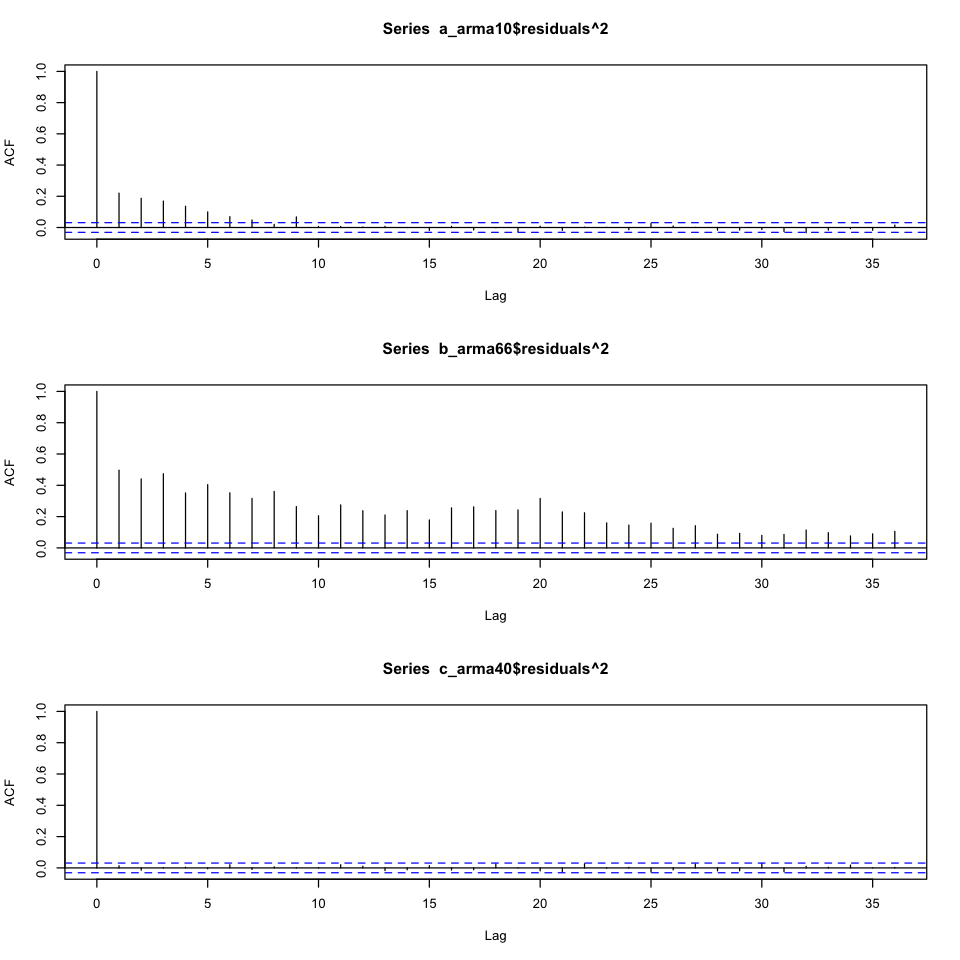

In [19]:
options(repr.plot.height=8, repr.plot.width=8)
par(mfrow=c(3,1))
acf(a_arma10$residuals^2)
acf(b_arma66$residuals^2)
acf(c_arma40$residuals^2)

ArchTest(a_arma10$residuals) #conditional heteroscedasticity test
ArchTest(b_arma66$residuals)
ArchTest(c_arma40$residuals)

Based on the ACFs and the cond. heteroscedasticity tests, we observe that series A and B are not accurately modeled, as there is residual autocorrelation in the squared residuals. These findings reflect the fact that ARMA models only manage to model the conditional mean, and are insufficient to model the conditional variance - need to fit a GARCH model.

The strong rejection of the null in Series A and B (as initially hypothesised) suggests that there are significant ARCH effects remaining after fitting ARMA (especially in Series B).

Meanwhile, Series C exhibits no significant residual^2 autocorrelation at lagged values. This suggessts that ARMA(4,0) is sufficient specification of the conditional mean - no evidence of ARCH effects, which aligns with our initial hypothesis from Problem 1.

- Since financial data tend to exhibit volatility clustering (conditinal heteroscedasticity), an ARMA model, which treats all observations equally (calm and turbulent period observations should not be treated as such) is not able to accurately fit such data. ARCH or GARCH models on the other hand, account for time varying estimates of $\sigma_t^2$, which can be used to standardise residuals. This leads to improvement in parameter estimation (when estimating parameters jointly ARMA-GARCH), as such a model accounts for heteroscedasticity in the error term. Consequently, we get better inference when we account for volatility clustering - otherwise heteroscedastic residuals would inflate SEs and make significance tests unreliable.

**In summary**: A review of the ACF plots and the results from the conditional heteroscedasticity test indicate that series A and B cannot be adequately modeled as they contain residual autocorrelation in their squared residuals. Both findings demonstrate that ARMA models are unable to model the conditional variance and therefore require a GARCH model to capture this component.

---

## Problem 4: Modeling conditional volatility

### Preferred ARMA specifications passed through from Problems 2 & 3

| Series | ARMA (Box-Jenkins) | ARMA for GARCH stage | Reason for revision |
|--------|-------------------|----------------------|---------------------|
| A | ARMA(1,0) | **ARMA(1,0)** | No change; clean identification |
| B | ARMA(6,6) *(provisional)* | **ARMA(1,0)** | Modified: Problem 3 demonstrated that high order lags capture GARCH influences as opposed to true mean dynamics; a parsimonious mean equation will serve as a more reasonable choice for estimating jointly |
| C | ARMA(4,0) | **ARMA(4,0)** | No change; clean identification |

The conditional variance equation applied to all three series is GARCH(1,1):

$$\sigma_t^2 = \omega + \alpha_1 \varepsilon_{t-1}^2 + \beta_1 \sigma_{t-1}^2$$

where $\omega > 0$ is the long-run variance intercept, $\alpha_1 \geq 0$ measures 
reactivity to lagged squared shocks (the ARCH effect), and $\beta_1 \geq 0$ captures 
persistence from the previous conditional variance (the GARCH effect).


In [ ]:
#Series A: Box-Jenkins identified a clean AR(1) structure with no signs
#of misspecification, so ARMA(1,0) is carried forward unchanged.
spec_A <- ugarchspec(
  variance.model = list(model = "sGARCH", garchOrder = c(1,1)),
  mean.model = list(armaOrder = c(1,0), include.mean = TRUE),
  distribution.model = "norm"
)

fit_A <- ugarchfit(spec = spec_A, 
                   data = seriesA$ret)

#Series B: the mean equation is revised down to ARMA(1,0).
#Problem 3 showed that the serial dependence left in the squared residuals after ARMA(6,6) is located in the conditional variance, not the mean.
#A parsimonious AR(1) is therefore the appropriate working mean here, leaving GARCH(1,1) to absorb the volatility dynamics.
spec_B <- ugarchspec(variance.model = list(model = "sGARCH", 
                                           garchOrder = c(1,1)),
                     mean.model = list(armaOrder = c(1,0), include.mean = TRUE),
                     distribution.model = "norm"
                    )

fit_B <- ugarchfit(spec = spec_B, 
                   data = seriesB$ret)

#Series C: ARMA(4,0) was previously established in Problem 2 and Problem 3 revealed no indication of ARCH effects; 
#hence, the specification remains unchanged.
spec_C <- ugarchspec(variance.model = list(model = "sGARCH", 
                                           garchOrder = c(1,1)),
                     mean.model = list(armaOrder = c(4,0), include.mean = TRUE),
                     distribution.model = "norm"
                    )

fit_C <- ugarchfit(spec = spec_C, data = seriesC$ret)

In [34]:
#fit_A 
#fit_B
#fit_C #notable beta coeff

### Estimated GARCH(1,1) parameters: ω, α₁, β₁

In [21]:
garch_params <- function(model_fit, series_name) {
  coefs <- coef(model_fit)
  persistence <- coefs["alpha1"] + coefs["beta1"]

  data.frame(Series = series_name,
             Omega = round(coefs["omega"], 6),
             Alpha1 = round(coefs["alpha1"], 4),
             Beta1 = round(coefs["beta1"], 4),
             Persistence = round(persistence, 4))
}

garch_table <- rbind(garch_params(fit_A, "Series A"),
                     garch_params(fit_B, "Series B"),
                     garch_params(fit_C, "Series C")
                    )

garch_table

,Series,Omega,Alpha1,Beta1,Persistence
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
omega,Series A,2.1e-05,0.1852,0.6030,0.7882
omega1,Series B,2.0e-05,0.2319,0.7503,0.9822
omega2,Series C,0.0e+00,0.0022,0.9957,0.9979


### Parameter explanation

Series A - ARMA(1,0)-GARCH(1,1)

- **ω** (omega): Estimated at 2.1e-05 is small but positive. Omega represents the baseline level of conditional variance that the process reverts to in the long run. This in turn suggests that in the absence of shocks, the conditional variance returns to a low but non-zero level.

- **α₁ (alpha1)**: Estimated at .1852. This represents how much a lagged "shock" affects todays' conditional variance. The value suggests that around 18.5% of last period's squared shock contributes to today's variance.

- **β₁ (beta1)**: Estimated at .6030. This means that around 60.3% of yesterday's estimated conditional variance carries into today (despite new shocks).

- **α₁ + β₁**: Estimated at .7882. This represents moderate to high persistence. In addition, since $\alpha + \beta < 1$, the variance will revert to its mean after any shock.

Series B - ARMA(1,0)-GARCH(1,1)

- **ω** (omega): Being nearly zero, the estimated ω is similar to Series A indicating the same unconditional variance baseline. The increased volatility characteristics of Series B are generated by the GARCH parameters rather than the intercept. 

- **α₁ (alpha1)**: The reactivity coefficient is largest (.2319). Therefore, Series B shows significant volatility increases after large shock events. The size of alpha1 causes significant jumps in conditional variance due to the squared innovation terms.

- **β₁ (beta1)**: The estimated beta1 of .75 is also large. Thus, once volatility rises significantly in Series B it tends to stay that way for several periods. With alpha1 and beta1 being very large, these represent the most persistent characteristic of a high-persistent GARCH model. Volatility shocks tend to be forgotten very slowly.

- **α₁ + β₁**: The largest persistence is exhibited by Series B with a persistence estimate of .9822 and very close to 1. Thus, the conditional variance shocks lose their influence very slowly.

Series C - ARMA(4,0)-GARCH(1,1)

- **ω** (omega): The estimated ω is effectively zero. This corresponds with our findings from Problem 3 that Series C contains virtually no ARCH effects. In general, conditional variance in Series C is near constant. 

- **α₁ (alpha1)**: Alpha1 is approximately 2.22e-03. As such, there is very little economic effect on conditional variance by new shocks. 

- **β₁ (beta1)**: Beta1 = 0.9957. This is close enough to 1 that one could treat it as equal. However, in a near-homoscedastic data set like Series C, the GARCH estimator can force beta into the region near 1 as an artifact of the optimizer.

- **α₁ + β₁**: Since this sum is 0.9979 (very close to 1), it is not economically relevant here either. The ARCH-LM test from Problem 3 did not indicate rejection of homoskedasticity therefore this fitted persistence measure is considered a boundary artifact and not an actual representation of the degree of volatility clustering.

### Persistence measure α₁ + β₁

The decay of a volatility shock follows the geometric sequence $(α_1 + β_1)^k$ 
for $k$ periods ahead. When the sum is close to 1 the shock dissipates very slowly 
(high persistence); when it is close to zero the shock vanishes almost immediately.
For the process to be covariance-stationary, we require α₁ + β₁ < 1.

Finally, we reject our initial hypothesis that Series A exhibits higher $\beta$ and therefore  longer lasting volatility persistence thant Series B.

### Full model output

In [22]:
print("Series A")
show(fit_A)

print("Series B")
show(fit_B)

print("Series C")
show(fit_C)

[1] "Series A"

*---------------------------------*
*          GARCH Model Fit        *
*---------------------------------*

Conditional Variance Dynamics 	
-----------------------------------
GARCH Model	: sGARCH(1,1)
Mean Model	: ARFIMA(1,0,0)
Distribution	: norm 

Optimal Parameters
------------------------------------
        Estimate  Std. Error  t value Pr(>|t|)
mu      0.000291    0.000179   1.6235  0.10448
ar1     0.193807    0.016827  11.5173  0.00000
omega   0.000021    0.000003   6.8473  0.00000
alpha1  0.185190    0.020144   9.1935  0.00000
beta1   0.603009    0.042442  14.2080  0.00000

Robust Standard Errors:
        Estimate  Std. Error  t value Pr(>|t|)
mu      0.000291    0.000173   1.6807 0.092821
ar1     0.193807    0.016668  11.6277 0.000000
omega   0.000021    0.000003   7.1942 0.000000
alpha1  0.185190    0.020333   9.1080 0.000000
beta1   0.603009    0.039987  15.0800 0.000000

LogLikelihood : 12858.15 

Information Criteria
------------------------------------
 

### Conditional volatility plots

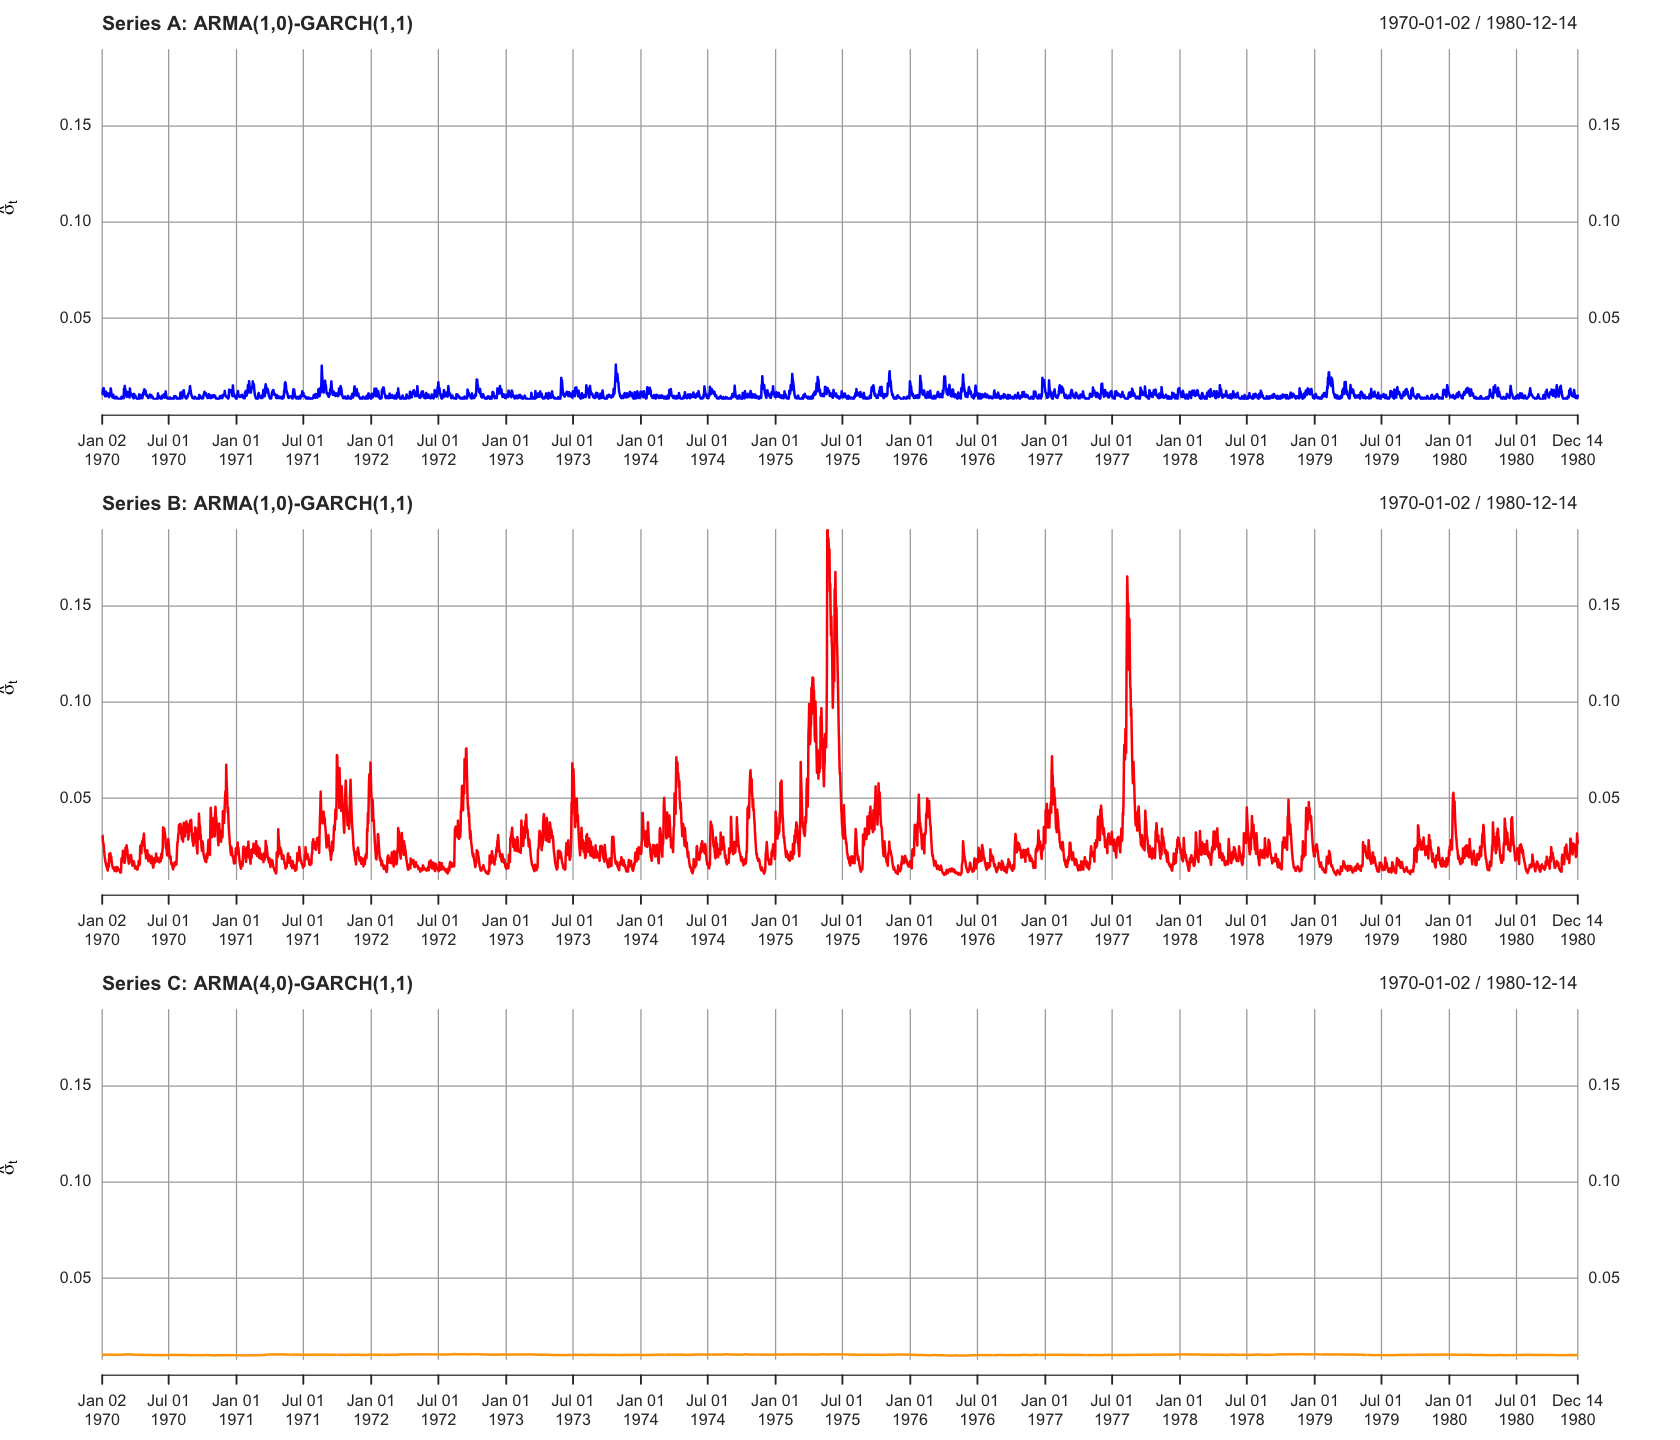

In [ ]:
options(repr.plot.height = 12, repr.plot.width = 14)
par(mfrow = c(3, 1), mar = c(4, 4, 3, 1))

vol_A <- sigma(fit_A)
vol_B <- sigma(fit_B)
vol_C <- sigma(fit_C)

ylim = range(c(vol_A, vol_B, vol_C)) #for apples-to-apples comparison

plot(vol_A, type = "l",
     main = "Series A: ARMA(1,0)-GARCH(1,1)",
     col = "blue",
     xlab = "Time",
     ylim = ylim, 
     ylab = expression(hat(sigma)[t]))


plot(vol_B, type = "l",
     main = "Series B: ARMA(1,0)-GARCH(1,1)",
     col = "red",
     xlab = "Time", 
     ylim = ylim, 
     ylab = expression(hat(sigma)[t]))

plot(vol_C, type = "l",
     main = "Series C: ARMA(4,0)-GARCH(1,1)",
     col = "orange",
     xlab = "Time",
     ylim = ylim,  
     ylab = expression(hat(sigma)[t]))

### Conditional volatility dynamics

**Series A** exhibits moderate conditional volatility throughout the sample. When a shock hits, we observe a meaningful variance reaction, although not to extreme levels as series B. In addition, the variance reverts back to its long-run level rather quickly. This is consistent with both $\alpha$ and $\beta$ being moderate.


**Series B** demonstrates the greatest degree of time-varying conditional volatility -- sharp large spikes followed by a prolonged period at elevated levels of volatility prior to reversion. This behavior is indicative of a high level of both α₁ (reaction to shock) and β₁ (slow rate of decay).

Following the revision of the mean specification from ARMA(6,6) to ARMA(1,0) , the GARCH is performing the correct function: it is absorbing the serial dependence that the higher order ARMA was capturing inaccurately.

**Series C** produces a nearly horizontal line for conditional volatility and provides no evidence of ARCH effects when using ARMA(4,0) residuals. Although the reported value of ω for the fitted GARCH(1,1) is effectively zero, the sum of the estimated values for α₁ and β₁ is very close to unity. Since ω is approximately zero, α₁ is small enough to be considered economically insignificant, and since including GARCH does little to improve the model overall, it can be concluded that Series C represents homoscedastic data and therefore estimates of persistence associated with GARCH are not economically significant.

### Classification
- **Most persistent meaningful GARCH effects:** Series B (highest level of persistence among all three series for which GARCH is economically justified)
- **Moderate GARCH effects:** Series A (evident clustering but less volatile and faster mean reversion compared to series B)
- **No/negligible GARCH effects:** Series C (no support from ARCH diagnostics for a meaningful GARCH effect; best to interpret boundary case as such)

## Problem 5: Comparing volatility persistence 

In [24]:
#Extracting GARCH coefficients
coef_A <- coef(fit_A)
coef_B <- coef(fit_B)
coef_C <- coef(fit_C)

#ARCH-LM test p-values from selected ARMA benchmark models
arch_p_A <- ArchTest(a_arma10$residuals)$p.value
arch_p_B <- ArchTest(b_arma66$residuals)$p.value
arch_p_C <- ArchTest(c_arma40$residuals)$p.value

#Building a summary table for all three series
classification_table <- data.frame(Series = c("Series A", "Series B", "Series C"),
                                   omega = c(coef_A["omega"],  coef_B["omega"],  coef_C["omega"]),
                                   alpha1 = c(coef_A["alpha1"], coef_B["alpha1"], coef_C["alpha1"]),
                                   beta1 = c(coef_A["beta1"],  coef_B["beta1"],  coef_C["beta1"]),
                                   Persistence = c(coef_A["alpha1"] + coef_A["beta1"],
                                                   coef_B["alpha1"] + coef_B["beta1"],
                                                   coef_C["alpha1"] + coef_C["beta1"]),
                                   ARCH_p_value = c(arch_p_A, arch_p_B, arch_p_C),
                                   Interpret_persistence = c(TRUE, TRUE, FALSE),
                                   Category = c("Moderate persistence",
                                                "High persistence",
                                                "No / negligible GARCH")
                                  )


classification_table

#Ranking only the series for which persistence is economically meaningful
ranked_persistence <- classification_table[order(-classification_table$Persistence), ]
rownames(ranked_persistence) <- NULL

ranked_persistence[, c("Series", "Persistence", "Category")]

Series,omega,alpha1,beta1,Persistence,ARCH_p_value,Interpret_persistence,Category
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<chr>
Series A,2.141644e-05,0.185190226,0.6030093,0.7881995,7.723699e-68,TRUE,Moderate persistence
Series B,2.041248e-05,0.231890367,0.7502642,0.9821546,2.424086e-316,TRUE,High persistence
Series C,2.151290e-07,0.002206712,0.9956791,0.9978858,9.095700e-01,FALSE,No / negligible GARCH


Series,Persistence,Category
<chr>,<dbl>,<chr>
Series C,0.9978858,No / negligible GARCH
Series B,0.9821546,High persistence
Series A,0.7881995,Moderate persistence


In [25]:
#Computing half-life: number of periods for a shock to decay to 50%

persistence_A <- coef_A["alpha1"] + coef_A["beta1"]
persistence_B <- coef_B["alpha1"] + coef_B["beta1"]

#(alpha + beta)^k = 0.5
halfl_A <- ceiling(log(0.5) / log(persistence_A)) #get an integer number from ceiling()
halfl_B <- ceiling(log(0.5) / log(persistence_B))

data.frame(Series = c("Series A", "Series B", "Series C"),
           Persistence = c(round(persistence_A, 4), 
                           round(persistence_B, 4), NA),
           Half_life = c(halfl_A, halfl_B, NA),
           Note = c("Moderate", "High", 
           "No meaningful GARCH effects")
          )

Series,Persistence,Half_life,Note
<chr>,<dbl>,<dbl>,<chr>
Series A,0.7882,3,Moderate
Series B,0.9822,39,High
Series C,NA,NA,No meaningful GARCH effects


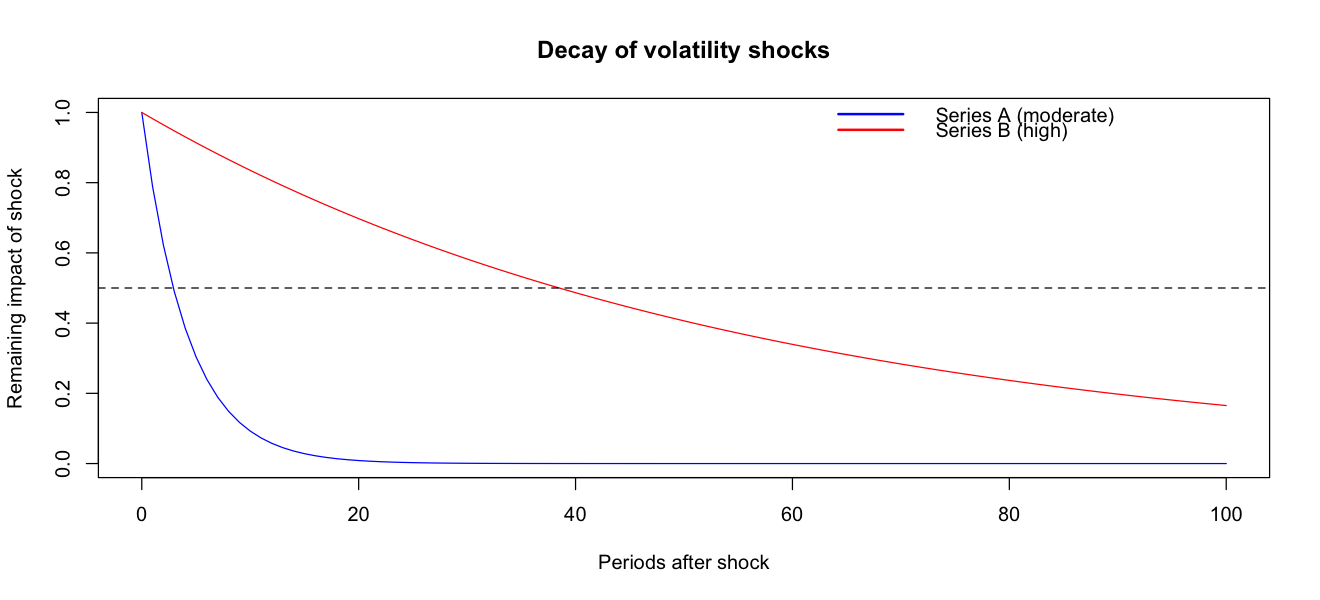

In [26]:
#Plotting how quickly a volatility shock fades over time

options(repr.plot.height = 5, repr.plot.width = 11)

horizon <- 100
periods <- 0:horizon

#Computing the decay path for the two series with supported GARCH effects
decay_A <- persistence_A^periods
decay_B <- persistence_B^periods

#Plotting the decay path for Series A
plot(periods, decay_A,
     type = "l",
     col = "blue",
     ylim = c(0, 1),
     xlab = "Periods after shock",
     ylab = "Remaining impact of shock",
     main = "Decay of volatility shocks"
    )

#Adding the decay path for Series B
lines(periods, decay_B, col = "red")

abline(h = 0.5, lty = 2)

legend("topright",
       legend = c("Series A (moderate)", "Series B (high)"),
       col = c("blue", "red"),
       lwd = 2,
       bty = "n"
      )

### Classification & discussion

**Persistence ranking (all three series):**

| Rank | Series | $\alpha_1 + \beta_1$ | Category | Supported by diagnostics? |
|------|--------|----------------------|----------|---------------------------|
| 1 | Series B | 0.9822 | High persistence | Yes |
| 2 | Series A | 0.7882 | Moderate persistence | Yes |
| 3 | Series C | 0.9979 | No / negligible GARCH | No;boundary artifact |

**Note:** Series C is ranked last despite its numerically high persistence because the ARCH-LM test does not reject homoskedasticity; the fitted $\alpha_1 + \beta_1$ is a boundary artifact of forcing GARCH(1,1) onto homoskedastic data and is not economically interpretable.

**How the classification is supported**

**Estimated parameters**
The GARCH models are based on diagnostic results from all three series; however, among those for which they are supported by these results, Series B has the highest level of persistence and the slowest rate of volatility decay. The same may be said about Series A, although it exhibits a clearer but less extreme level of persistence. Series C, however, is subject to an estimated near unit persistence due to a mechanical aspect of the GARCH model. However, this should not be viewed as indicative of actual volatility clustering since the ARCH LM test indicates homoscedasticity and the GARCH model specifications were not supported by the diagnostics.

**Behavior of conditional volatility**
Conditional volatility in Series B tends to explode into large spikes that last for extensive intervals then rapidly decline. Conditional volatility in Series A exhibits relatively mild and smooth movements around its unconditional mean. On the other hand, there appears to be no variation over time in the variance of Series C (i.e., the conditional σ̂ₜ is essentially flat).

**Volatility clustering in raw data**
Both plots of returns (and returns^2) for Series B exhibit long stretches of time during which there is little or no movement in returns followed by short periods of extremely rapid changes (a classic example of high-persistence clustering). While both plots of returns for Series A appear to cluster together to some extent, it is not nearly as pronounced as for Series B. Furthermore, plots of returns for Series C appear to be homoscedastic throughout and do not exhibit any type of clustering. 

**Effect of persistence on rate of shock decay**
Whereas GARCH was supported by diagnostics for Series A and B, the rate at which a shock to volatility decays from a particular point t follows a geometric sequence $(α₁ + β₁)^k$ for k periods subsequent to t.

- When α₁ + β₁ ≈ **1**, the rate of decay will be quite slow. In the case of **Series B**, this means that shocks to volatility can affect future values for many periods.
- When α₁ + β₁ < **1**, the rate of decay will be faster. In the case of **Series A**, we observe clustering; however, these clusters dissipate fairly quickly.
- For **Series C**, this relationship is not given economic interpretation. Although α₁ + β₁ is numerically close to **1** for Series C, the diagnostics indicate that GARCH effects are not real; therefore, our treatment of this calculated value for persistence is that it represents an artificial boundary and does not represent slow volatility decay.

## Problem 6: Joint modeling of mean & volatility

The results obtained by fitting the pure ARMA models to the data set used in problem 2 will be compared with those of the joint ARMA-GARCH models fitted to the same data set in problem 4. In addition to comparing these two types of models, we also seek to answer three specific questions:

1. Does taking into account **conditional heterogeneity** affect either the **magnitude** of the mean (i.e., the ARMA) parameters or their **statistical significance**?

2. Are there **improvements in residual diagnostic measures**, such as white noise tests and other residual analysis, when a GARCH model is added to an ARMA model?

3. What does **simultaneous estimation** of the mean and volatility components contribute to the overall goal of using financial econometric models?

In [ ]:
#Reloading pure-ARMA models from Problem 2
fit_A_arma <- Arima(seriesA$ret, order = c(1,0,0))
fit_B_arma <- Arima(seriesB$ret, order = c(6,0,6))
fit_C_arma <- Arima(seriesC$ret, order = c(4,0,0))

#Series A: comparing ARMA(1,0) with ARMA(1,0)-GARCH(1,1)

a_coef_A <- coef(fit_A_arma)
a_se_A <- sqrt(diag(vcov(fit_A_arma)))

g_coef_A <- coef(fit_A)
g_se_A <- sqrt(diag(vcov(fit_A)))
mean_idx_A <- !names(g_coef_A) %in% c("omega","alpha1","beta1")

data.frame(Parameter = names(a_coef_A),
           ARMA_coef = round(a_coef_A, 6),
           ARMA_se = round(a_se_A, 6),
           ARMA_t = round(a_coef_A / a_se_A, 3),
           ARMA_p = round(2 * (1 - pnorm(abs(a_coef_A / a_se_A))), 4),
           GARCH_coef = round(g_coef_A[mean_idx_A], 6),
           GARCH_se = round(g_se_A[mean_idx_A], 6),
           GARCH_t = round(g_coef_A[mean_idx_A] / g_se_A[mean_idx_A], 3),
           GARCH_p = round(2 * (1 - pnorm(abs(g_coef_A[mean_idx_A] / g_se_A[mean_idx_A]))), 4),
           row.names = NULL
          )

#Series B: comparing ARMA(6,6) with ARMA(1,0)-GARCH(1,1)
#Note: mean spec changed from (6,6) to (1,0) at GARCH stage,
#so only common parameters (mu) can be compared directly

a_coef_B <- coef(fit_B_arma)
a_se_B <- sqrt(diag(vcov(fit_B_arma)))

g_coef_B <- coef(fit_B)
g_se_B <- sqrt(diag(vcov(fit_B)))
mean_idx_B <- !names(g_coef_B) %in% c("omega","alpha1","beta1")

#ARMA(6,6) parameters
data.frame(Parameter = names(a_coef_B),
           ARMA_coef = round(a_coef_B, 6),
           ARMA_se = round(a_se_B, 6),
           ARMA_t = round(a_coef_B / a_se_B, 3),
           ARMA_p = round(2 * (1 - pnorm(abs(a_coef_B / a_se_B))), 4),
           row.names = NULL
          )

#ARMA(1,0)-GARCH(1,1) mean parameters
data.frame(Parameter = names(g_coef_B[mean_idx_B]),
           GARCH_coef = round(g_coef_B[mean_idx_B], 6),
           GARCH_se = round(g_se_B[mean_idx_B], 6),
           GARCH_t = round(g_coef_B[mean_idx_B] / g_se_B[mean_idx_B], 3),
           GARCH_p = round(2 * (1 - pnorm(abs(g_coef_B[mean_idx_B] / g_se_B[mean_idx_B]))), 4),
           row.names = NULL
          )

#Series C: comparing ARMA(4,0) with ARMA(4,0)-GARCH(1,1)

a_coef_C <- coef(fit_C_arma)
a_se_C <- sqrt(diag(vcov(fit_C_arma)))

g_coef_C <- coef(fit_C)
g_se_C <- sqrt(diag(vcov(fit_C)))
mean_idx_C <- !names(g_coef_C) %in% c("omega","alpha1","beta1")

data.frame(Parameter = names(a_coef_C),
           ARMA_coef = round(a_coef_C, 6),
           ARMA_se = round(a_se_C, 6),
           ARMA_t = round(a_coef_C / a_se_C, 3),
           ARMA_p = round(2 * (1 - pnorm(abs(a_coef_C / a_se_C))), 4),
           GARCH_coef = round(g_coef_C[mean_idx_C], 6),
           GARCH_se = round(g_se_C[mean_idx_C], 6),
           GARCH_t = round(g_coef_C[mean_idx_C] / g_se_C[mean_idx_C], 3),
           GARCH_p = round(2 * (1 - pnorm(abs(g_coef_C[mean_idx_C] / g_se_C[mean_idx_C]))), 4),
           row.names = NULL
          )

Parameter,ARMA_coef,ARMA_se,ARMA_t,ARMA_p,GARCH_coef,GARCH_se,GARCH_t,GARCH_p
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ar1,0.203630,0.015478,13.156,0.0000,0.000291,0.000179,1.623,0.1045
intercept,0.000215,0.000201,1.070,0.2848,0.193807,0.016827,11.517,0.0000


Parameter,ARMA_coef,ARMA_se,ARMA_t,ARMA_p
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
ar1,0.802939,0.268217,2.994,0.0028
ar2,-1.226826,0.210598,-5.825,0.0000
ar3,0.317675,0.390125,0.814,0.4155
ar4,-0.568365,0.247537,-2.296,0.0217
ar5,0.076698,0.205530,0.373,0.7090
ar6,-0.354291,0.098334,-3.603,0.0003
ma1,-0.569641,0.270652,-2.105,0.0353
ma2,1.005549,0.164475,6.114,0.0000
ma3,0.008524,0.344540,0.025,0.9803


Parameter,GARCH_coef,GARCH_se,GARCH_t,GARCH_p
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
mu,-0.000411,0.000337,-1.218,0.2232
ar1,0.178247,0.016527,10.785,0.0000


Parameter,ARMA_coef,ARMA_se,ARMA_t,ARMA_p,GARCH_coef,GARCH_se,GARCH_t,GARCH_p
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ar1,0.214377,0.015798,13.570,0.0000,0.000096,0.000199,0.483,0.6293
ar2,-0.061071,0.016158,-3.780,0.0002,0.211605,0.015830,13.368,0.0000
ar3,0.012453,0.016162,0.770,0.4410,-0.054613,0.016169,-3.378,0.0007
ar4,0.033150,0.015806,2.097,0.0360,0.010044,0.016176,0.621,0.5347
intercept,0.000163,0.000200,0.814,0.4156,0.032033,0.015829,2.024,0.0430


In [28]:
#Comparing information criteria for ARMA-only and ARMA-GARCH models
#rugarch reports AIC and BIC per observation, so we multiply by the sample size to make them comparable with the values returned by Arima()

sample_size <- 4000

info_criteria <- data.frame(Series = c("A", "A", "B", "B", "C", "C"),
                            Model = c("ARMA(1,0)", "ARMA(1,0)-GARCH(1,1)",
                                      "ARMA(6,6)", "ARMA(1,0)-GARCH(1,1)",
                                      "ARMA(4,0)", "ARMA(4,0)-GARCH(1,1)"),
                            AIC = c(fit_A_arma$aic, infocriteria(fit_A)[1] * sample_size,
                                    fit_B_arma$aic, infocriteria(fit_B)[1] * sample_size,
                                    fit_C_arma$aic, infocriteria(fit_C)[1] * sample_size),
                            BIC = c(fit_A_arma$bic, infocriteria(fit_A)[2] * sample_size,
                                    fit_B_arma$bic, infocriteria(fit_B)[2] * sample_size,
                                    fit_C_arma$bic, infocriteria(fit_C)[2] * sample_size)
                           )

info_criteria

Series,Model,AIC,BIC
<chr>,<chr>,<dbl>,<dbl>
A,"ARMA(1,0)",-25411.36,-25392.47
A,"ARMA(1,0)-GARCH(1,1)",-25706.30,-25674.83
B,"ARMA(6,6)",-16570.41,-16482.29
B,"ARMA(1,0)-GARCH(1,1)",-19088.23,-19056.76
C,"ARMA(4,0)",-25389.97,-25352.20
C,"ARMA(4,0)-GARCH(1,1)",-25381.23,-25330.88


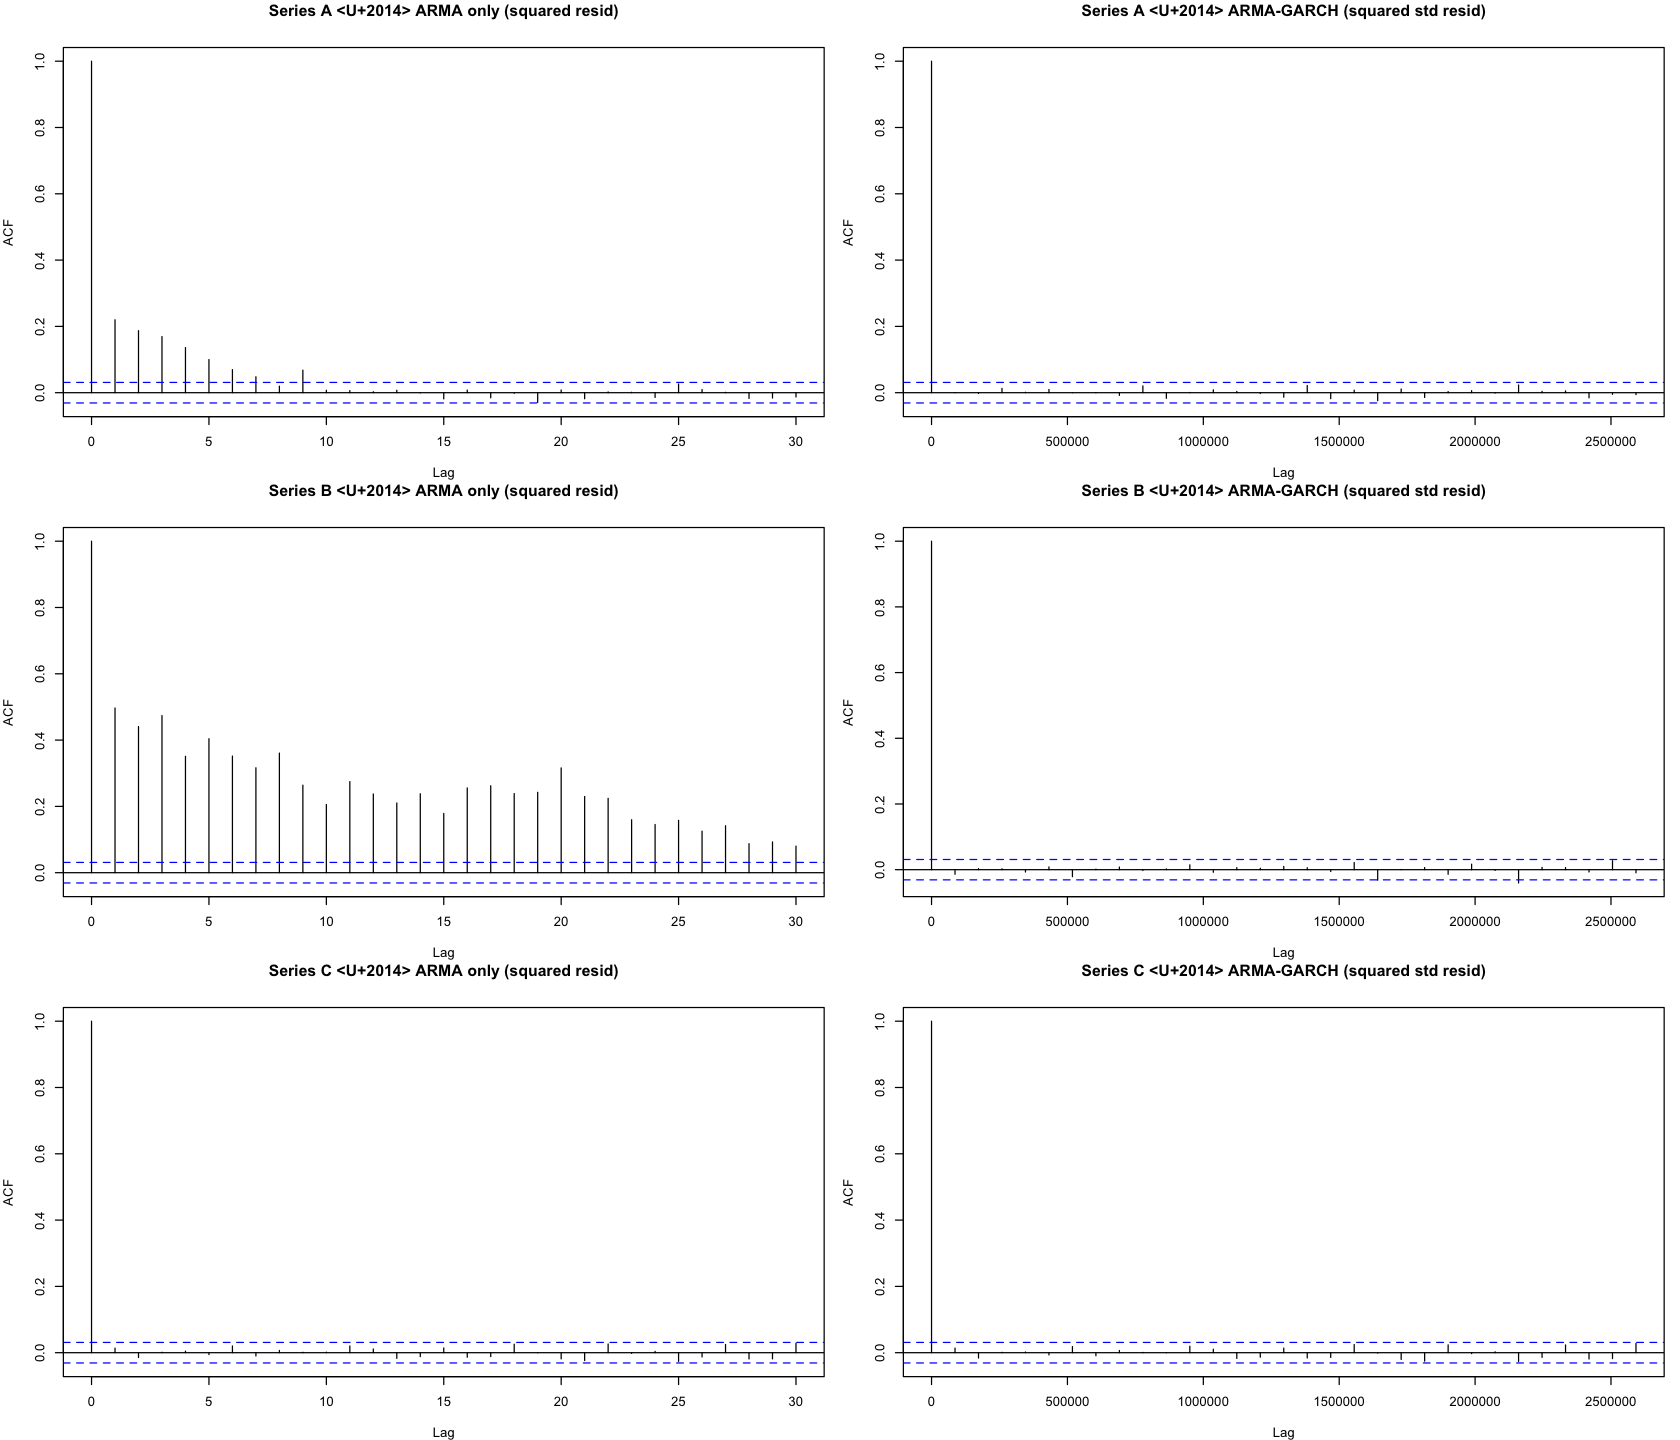

In [29]:
#Comparing residuals squared: ARMA-only (left) vs ARMA-GARCH standardized (right)

options(repr.plot.height = 12, repr.plot.width = 14)
par(mfrow = c(3, 2), mar = c(4, 4, 3, 1))

#Extracting standardized residuals from GARCH fits
std_residual_A <- residuals(fit_A, standardize = TRUE)
std_residual_B <- residuals(fit_B, standardize = TRUE)
std_residual_C <- residuals(fit_C, standardize = TRUE)

#Series A
acf(fit_A_arma$residuals^2, main = "Series A — ARMA only (squared resid)", lag.max = 30)
acf(std_residual_A^2, main = "Series A — ARMA-GARCH (squared std resid)", lag.max = 30)

#Series B
acf(fit_B_arma$residuals^2, main = "Series B — ARMA only (squared resid)", lag.max = 30)
acf(std_residual_B^2, main = "Series B — ARMA-GARCH (squared std resid)", lag.max = 30)

#Series C
acf(fit_C_arma$residuals^2, main = "Series C — ARMA only (squared resid)", lag.max = 30)
acf(std_residual_C^2, main = "Series C — ARMA-GARCH (squared std resid)", lag.max = 30)

In [30]:
#ARCH tests for residuals from the ARMA-only models
ArchTest(fit_A_arma$residuals) #Series A
ArchTest(fit_B_arma$residuals) #Series B
ArchTest(fit_C_arma$residuals) #Series C

#ARCH tests for standardized residuals from the ARMA-GARCH models
ArchTest(as.numeric(std_residual_A)) #Series A
ArchTest(as.numeric(std_residual_B)) #Series B
ArchTest(as.numeric(std_residual_C)) #Series C


	ARCH LM-test; Null hypothesis: no ARCH effects

data:  fit_A_arma$residuals
Chi-squared = 351.23, df = 12, p-value < 2.2e-16



	ARCH LM-test; Null hypothesis: no ARCH effects

data:  fit_B_arma$residuals
Chi-squared = 1510.2, df = 12, p-value < 2.2e-16



	ARCH LM-test; Null hypothesis: no ARCH effects

data:  fit_C_arma$residuals
Chi-squared = 6.1265, df = 12, p-value = 0.9096



	ARCH LM-test; Null hypothesis: no ARCH effects

data:  as.numeric(std_residual_A)
Chi-squared = 4.5181, df = 12, p-value = 0.9722



	ARCH LM-test; Null hypothesis: no ARCH effects

data:  as.numeric(std_residual_B)
Chi-squared = 4.5859, df = 12, p-value = 0.9704



	ARCH LM-test; Null hypothesis: no ARCH effects

data:  as.numeric(std_residual_C)
Chi-squared = 5.7271, df = 12, p-value = 0.9292


### Discussion

#### Does accounting for heteroscedasticity change the estimates of the mean parameters?

Theory states that if you perform an Ordinary Least Squares or Conditional Maximum Likelihood Estimation (OLS/C-MLE) on a dataset that includes heteroscedasticity, you will obtain consistent estimates for your parameter estimates, but **your estimates will be less efficient** -- your **parameter estimates** for the mean will be unbiased, but your **standard error** will be larger than it would have been under correct weighting (due to the fact that the standard deviation varies over the entire sample period).

When performing a full maximum likelihood estimation (MLE) to estimate both the ARMA portion of your model, and the GARCH variance equation simultaneously, the likelihood function correctly assigns a weight of $1/\sigma_{t}^{2}$ to each observation. Since $\sigma_{t}^{2}$ varies with time, observations in periods of high volatility are assigned lower weights. 

As illustrated in the Table below comparing the fits from two types of estimations:

- **Series A**: Because this series actually exhibits conditional heteroscedasticity, when we use the joint ARMA/GARCH estimation for Series A, we alter the **precision** or **estimated uncertainty** of the mean parameters relative to the ARMA-only fit. Although the **point estimates** for the parameters did not vary much, the **standard errors** did change because of the proper weighting of observations based upon their time-varying volatility.

- **Series B**: For this series, the **comparative analysis** is between an ARMA(6,6) model estimated in Problem 2 and an ARMA(1,0)-GARCH(1,1) model estimated in Problem 4. Additionally, since Problem 3 indicated that any additional ARMA terms added to capture the variance contaminating the mean rather than capture any type of dynamic relationship among the variables included in the mean equation, the differences in coefficients represent both the **re-weighting** effect of jointly estimating both the mean and variance equations and the changes in specifications of the mean equation. This comparative analysis could therefore be considered somewhat **indirect** as compared to that of Series A and C; however, it does illustrate another fundamental concept: ignoring conditional heteroscedasticity can lead to misidentifying mean relationships.

- **Series C**: Given that there is virtually no evidence of GARCH effects, the coefficients estimates and standard errors from the ARMA-only fit and ARMA-GARCH fit are nearly identical

#### Do residual diagnostic tests improve once we have modeled conditional volatility?

**Yes, considerably** for Series A and B. The autocorrelation functions (ACFs) of squared residuals from solely fitted ARMA models exhibit positive correlation at multiple lags (as shown in results of ARCH tests); which demonstrates that some kind of dependence in conditional variance was unaccounted for. However, once a GARCH(1,1) component was added to the model:

- The ACF of standardized residuals ($\epsilon \hat{t}/\sigma \hat{t}$) drops well within the limits of confidence intervals; indicating that GARCH filter has successfully identified all of the variance clustering.
- The p-values associated with ARCH test results increase substantially (thus failing to reject the null hypothesis of no ARCH effects).

**Series C**, already had no ARCH effects after fitting an ARMA(4,0) model; inclusion of GARCH(1,1) components provide minimal improvement and both residual diagnostic plots appear to be equally clean.

### Why is it important to model both the mean and variance simultaneously in financial econometrics?

There are three main reasons why modeling both the mean and variance is extremely important in financial econometrics:

1. **Efficiency** -- When employing a likelihood function that uses suitable weights based upon conditional variance ($\sigma_{t}^{2}$), the estimated parameters of the mean will have reduced **variance** (i.e. smaller standard errors). If we ignore heteroscedasticity, then our estimated **variance** will be inflated -- resulting in unreliably small p-values (and thus potentially misleading conclusions about which ARMA lag variables are statistically significant).

2. **Valid inference** -- Most statistical tests employed to evaluate hypotheses about ARMA residuals employ IID (independently and identically distributed) errors. If our residuals are heteroscedastic, then these tests are **invalid**. Utilizing a joint model of variance provides us with **valid statistical inference**.

4. **Forecasts of risk** -- In finance, the conditional variance ($\sigma_{t}^{2}$) is frequently a focus of interest for purposes such as portfolio optimization, derivative valuation and forecasting value-at-risk. Pure ARMA models treat variance as constant and cannot generate **time-varying risk forecasts**. The ARMA-GARCH model generates both a **forecast for the future mean and a forecast for future volatility at every horizon**; which is typical in financial risk management